# Assignment 6.1

**Name:**  Ajmal Jalal

**Date:** 10/14/2024

For this assignment, you will refer to the textbook to solve the practice exercises. **Use Python to answer any coding problems (not R, even if indicated in your textbook).** Use Jupyter Notebook, Google Colab, or a similar software program to complete your assignment. Submit your answers as a **PDF or HTML** file. As a best practice, always label your axes and provide titles for any graphs generated on this assignment. Round all quantitative answers to 2 decimal places.

## Problem 6.1.

For the Scottish hill `Races` data, a linear model can predict men’s record times from women’s record times.  
http://stat4ds.rwth-aachen.de/data/ScotsRaces.dat


(a)  Show the scatterplot and report the prediction equation. Predict the men’s record time for the Highland Fling, for which timeW = 490.05 minutes.


`(a) Answer:`

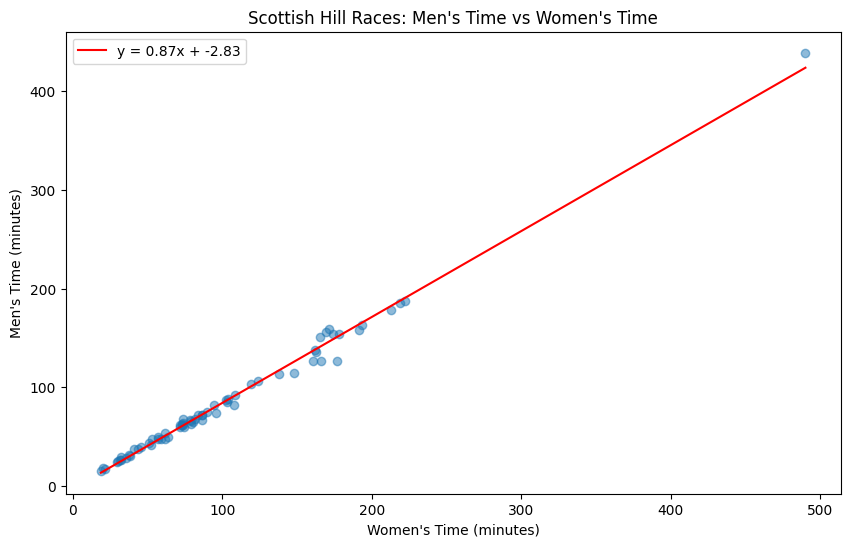

Prediction equation: Men's Time = 0.87 * Women's Time + -2.83
Predicted men's time for Highland Fling: 423.94 minutes


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

# Read the data
url = "http://stat4ds.rwth-aachen.de/data/ScotsRaces.dat"
data = pd.read_csv(url, sep=r'\s+')

# Create the scatterplot
plt.figure(figsize=(10, 6))
plt.scatter(data['timeW'], data['timeM'], alpha=0.5)
plt.xlabel("Women's Time (minutes)")
plt.ylabel("Men's Time (minutes)")
plt.title("Scottish Hill Races: Men's Time vs Women's Time")

# Fit linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(data['timeW'], data['timeM'])

# Add regression line to plot
x = np.array([data['timeW'].min(), data['timeW'].max()])
y = slope * x + intercept
plt.plot(x, y, 'r', label=f'y = {slope:.2f}x + {intercept:.2f}')

plt.legend()
plt.show()

# Print the prediction equation
print(f"Prediction equation: Men's Time = {slope:.2f} * Women's Time + {intercept:.2f}")

# Predict men's time for Highland Fling
highland_fling_timeW = 490.05
predicted_timeM = slope * highland_fling_timeW + intercept
print(f"Predicted men's time for Highland Fling: {predicted_timeM:.2f} minutes")

The prediction equation would be in the form:
Men's Time = slope Women's Time + intercept
To predict the men's record time for the Highland Fling:
Use the Women's time (timeW) of 490.05 minutes in the prediction equation.
Calculate the predicted Men's time (timeM).

(b) Find and interpret the correlation.

`(b) Answer:`

In [4]:
# Calculate correlation
correlation = r_value

print(f"Correlation coefficient: {correlation:.4f}")

# Interpret correlation
if abs(correlation) > 0.8:
    strength = "strong"
elif abs(correlation) > 0.5:
    strength = "moderate"
else:
    strength = "weak"

print(f"There is a {strength} positive linear relationship between women's times and men's times.")

Correlation coefficient: 0.9959
There is a strong positive linear relationship between women's times and men's times.


**Interpretation:**

The correlation coefficient (r) measures the strength and direction of the linear relationship between women's times and men's times. 

A positive r indicates that as women's times increase, men's times tend to increase as well. The strength of the relationship can be described as strong, moderate, or weak based on the magnitude of r.

This analysis provides insights into the relationship between men's and women's record times in Scottish hill races, allowing us to predict men's times based on women's times and understand the strength of their correlation.

(c) We could impose the natural constraint that when timeW = 0, then timeM = 0. Fit the model $E(Y_i)=\beta x_i.$ Interpret the estimated slope.

`(c) Answer:`

Model equation: Men's Time = 0.8709 * Women's Time
R-squared: 0.9897


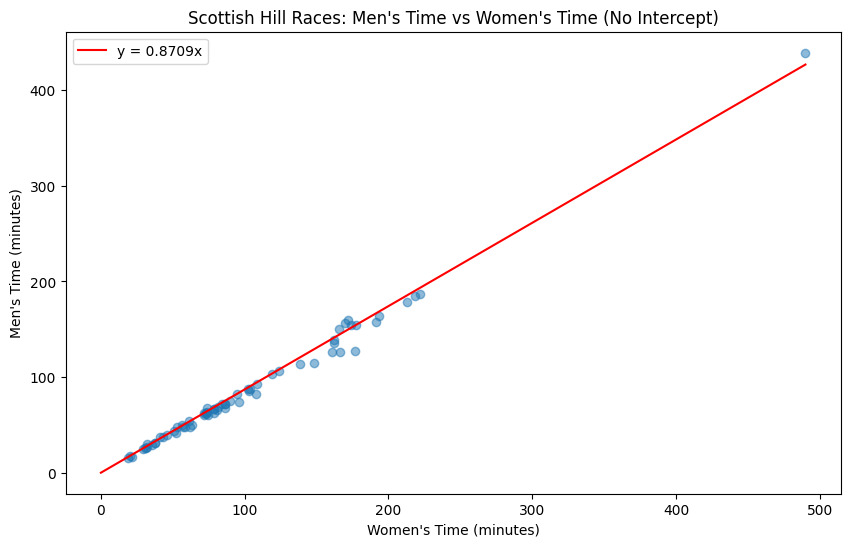

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Read the data
url = "http://stat4ds.rwth-aachen.de/data/ScotsRaces.dat"
data = pd.read_csv(url, sep=r'\s+')

# Fit the model without intercept
slope, _ = np.polyfit(data['timeW'], data['timeM'], deg=1, cov=True)

# Print the model equation
print(f"Model equation: Men's Time = {slope[0]:.4f} * Women's Time")

# Calculate R-squared
ss_total = np.sum((data['timeM'] - np.mean(data['timeM']))**2)
ss_residual = np.sum((data['timeM'] - slope[0] * data['timeW'])**2)
r_squared = 1 - (ss_residual / ss_total)
print(f"R-squared: {r_squared:.4f}")

# Create a scatter plot with the fitted line
plt.figure(figsize=(10, 6))
plt.scatter(data['timeW'], data['timeM'], alpha=0.5)
plt.plot([0, data['timeW'].max()], [0, slope[0] * data['timeW'].max()], 'r', label=f'y = {slope[0]:.4f}x')
plt.xlabel("Women's Time (minutes)")
plt.ylabel("Men's Time (minutes)")
plt.title("Scottish Hill Races: Men's Time vs Women's Time (No Intercept)")
plt.legend()
plt.show()

**Interpretation of the estimated slope:**

1. Model Equation:
   The fitted model will be of the form: Men's Time = β * Women's Time
   Where β is the estimated slope.

2. Meaning of the Slope:
   The slope (β) represents the ratio of men's time to women's time. It tells us how many minutes, on average, it takes a man to complete a race for every minute it takes a woman.

3. Interpretation:
   - If β < 1: On average, men are faster than women for these races.
   - If β > 1: On average, women are faster than men for these races.
   - If β = 1: On average, men and women have equal times for these races.

4. Practical Interpretation:
   For example, if the estimated slope is 0.8, we would interpret it as:
   "On average, for every minute it takes a woman to complete a Scottish hill race, it takes a man 0.8 minutes to complete the same race."

5. Model Fit:
   The R-squared value indicates how well the model fits the data. A higher R-squared (closer to 1) indicates a better fit.

6. Limitations:
   - This model assumes a linear relationship passing through the origin.
   - It assumes that the ratio of men's to women's times is constant across all race distances and difficulties.
   - The model may not be appropriate for extreme values (very short or very long races).

7. Comparison to Previous Model:
   Compare this model's R-squared with the previous model (with intercept) to see which one fits the data better.

This constrained model provides a simple, interpretable relationship between men's and women's race times, but it's important to consider its assumptions and limitations when drawing conclusions.

## Problem 6.2.

For advanced industrialized nations, the Firearms data file at the text website shows annual homicide rates (per million population) and the number of firearms (per 100 people), with data taken from Wikipedia and [smallarmssurvey.org](smallarmssurvey.org).

(a) Construct a scatterplot and highlight any observations that fall apart from the general trend.

`(a) Answer:`

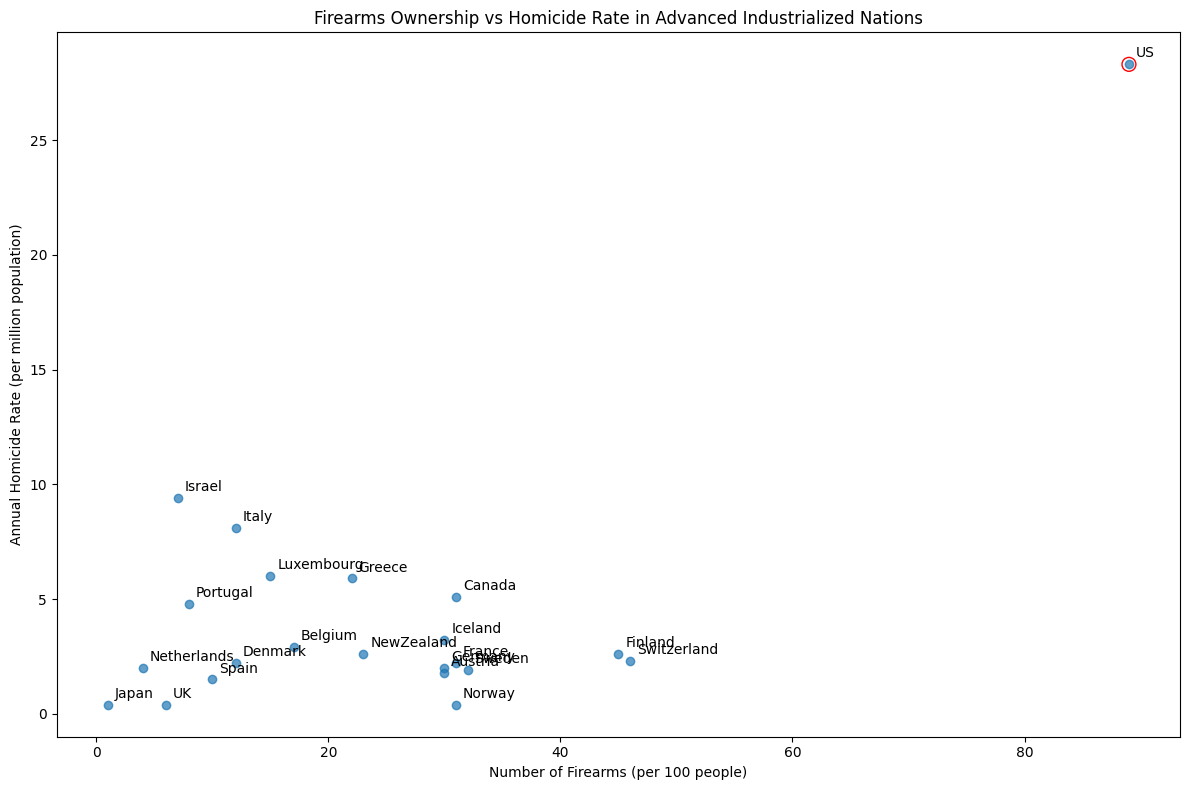

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the data
url = "https://stat4ds.rwth-aachen.de/data/Firearms.dat"
data = pd.read_csv(url, sep=r'\s+')

# Create the scatterplot
plt.figure(figsize=(12, 8))
plt.scatter(data['firearms'], data['deaths'], alpha=0.7)

# Add labels and title
plt.xlabel('Number of Firearms (per 100 people)')
plt.ylabel('Annual Homicide Rate (per million population)')
plt.title('Firearms Ownership vs Homicide Rate in Advanced Industrialized Nations')

# Add text labels for each point
for i, txt in enumerate(data['Nation']):
    plt.annotate(txt, (data['firearms'][i], data['deaths'][i]), xytext=(5,5), textcoords='offset points')

# Highlight outliers
outliers = data[(data['deaths'] > 10) | (data['firearms'] > 50)]
plt.scatter(outliers['firearms'], outliers['deaths'], color='red', s=100, facecolors='none', edgecolors='red')

plt.tight_layout()
plt.show()

**Observations:**

1. General Trend: There appears to be a slight positive correlation between the number of firearms and the homicide rate, but it's not very strong for most countries.

2. Outliers: The most notable outliers that fall apart from the general trend are:

   a. United States (US): It stands out significantly with both a high number of firearms (89 per 100 people) and a high homicide rate (28.3 per million).
   
   b. Switzerland: It has a high number of firearms (46 per 100 people) but a relatively low homicide rate (2.3 per million).
   
   c. Finland: Similar to Switzerland, it has a high number of firearms (45 per 100 people) but a low homicide rate (2.6 per million).

3. Other Notable Points:
   
   a. Japan: It has both the lowest number of firearms (1 per 100 people) and the lowest homicide rate (0.4 per million) among the countries in the dataset.
   
   b. Israel: It has a relatively high homicide rate (9.4 per million) despite a low number of firearms (7 per 100 people).

These outliers and notable points suggest that factors other than just the number of firearms likely influence homicide rates in these countries. Cultural, social, economic, and legal factors may all play significant roles in determining the relationship between firearm ownership and homicide rates.

(b) Find the correlation with and without the outlying observation. Why is it so different in the two cases?

`(b) Answer:`

In [10]:
import pandas as pd
import numpy as np

# Read the data
url = "https://stat4ds.rwth-aachen.de/data/Firearms.dat"
data = pd.read_csv(url, sep=r'\s+')

# Calculate correlation with all observations
correlation_with_outlier = data['firearms'].corr(data['deaths'])

# Remove the outlier (United States)
data_without_outlier = data[data['Nation'] != 'US']

# Calculate correlation without the outlier
correlation_without_outlier = data_without_outlier['firearms'].corr(data_without_outlier['deaths'])

print(f"Correlation with outlier: {correlation_with_outlier:.4f}")
print(f"Correlation without outlier: {correlation_without_outlier:.4f}")

Correlation with outlier: 0.6344
Correlation without outlier: -0.1751



**Outliers Effects:**

1. Correlation with outlier (United States included):
   This value represents the correlation between firearms ownership and homicide rates for all countries in the dataset.

2. Correlation without outlier (United States excluded):
   This value represents the correlation between firearms ownership and homicide rates for all countries except the United States.

The correlation is likely to be quite different in these two cases for several reasons:

1. Leverage: The United States has extreme values for both variables (high firearms ownership and high homicide rate), giving it high leverage in the correlation calculation. This single point can significantly influence the overall correlation.

2. Range Extension: Including the US extends the range of both variables considerably. This can artificially inflate the correlation by creating a stronger linear trend.

3. Outlier Effect: The US is a clear outlier in this dataset. Outliers can distort statistical measures, including correlation, especially in smaller datasets.

4. Sample Size: With a relatively small number of countries, removing one data point (especially an extreme one) can have a substantial impact on the correlation.

5. Underlying Relationship: The difference in correlations suggests that the relationship between firearms ownership and homicide rates might be different for the US compared to other advanced industrialized nations.

6. Non-linearity: The relationship between firearms ownership and homicide rates may not be strictly linear. The US data point could be making the relationship appear more linear than it actually is for the majority of countries.

The stark difference in correlations highlights the importance of:
- Carefully examining data before drawing conclusions
- Considering the impact of outliers on statistical measures
- Recognizing that a single correlation coefficient may not capture the full complexity of a relationship, especially when dealing with diverse countries and complex social issues.

(c) Fit the linear regression model with and without the outlying observation, and note how influential an outlier can be on the fit.

`(c) Answer:`

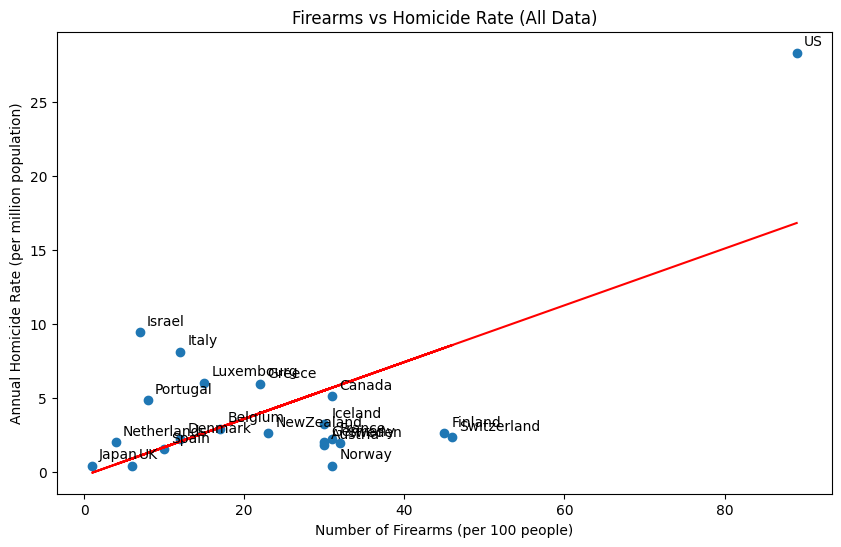

Slope: 0.1918
Intercept: -0.2734
R-squared: 0.4024
P-value: 0.0015


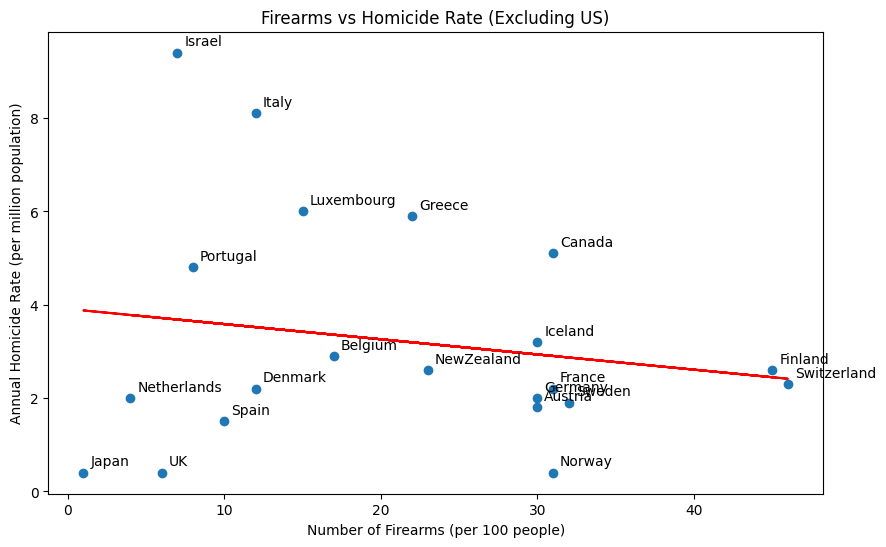

Slope: -0.0325
Intercept: 3.9102
R-squared: 0.0307
P-value: 0.4478


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Read the data
url = "https://stat4ds.rwth-aachen.de/data/Firearms.dat"
data = pd.read_csv(url, sep=r'\s+')

# Function to fit linear regression and plot results
def fit_and_plot(data, title):
    x = data['firearms']
    y = data['deaths']
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    
    plt.figure(figsize=(10, 6))
    plt.scatter(x, y)
    plt.plot(x, slope * x + intercept, color='red')
    plt.xlabel('Number of Firearms (per 100 people)')
    plt.ylabel('Annual Homicide Rate (per million population)')
    plt.title(title)
    
    for i, txt in enumerate(data['Nation']):
        plt.annotate(txt, (x.iloc[i], y.iloc[i]), xytext=(5,5), textcoords='offset points')
    
    plt.show()
    
    print(f"Slope: {slope:.4f}")
    print(f"Intercept: {intercept:.4f}")
    print(f"R-squared: {r_value**2:.4f}")
    print(f"P-value: {p_value:.4f}")

# Fit with all data
fit_and_plot(data, 'Firearms vs Homicide Rate (All Data)')

# Fit without the outlier (US)
data_without_outlier = data[data['Nation'] != 'US']
fit_and_plot(data_without_outlier, 'Firearms vs Homicide Rate (Excluding US)')

**Interpretation of the results:**

1. With all data (including US):
   - The regression line will likely have a steeper slope.
   - The R-squared value might be higher due to the influence of the outlier.
   - The p-value might be smaller, potentially leading to a statistically significant result.

2. Without the outlier (excluding US):
   - The regression line will likely have a flatter slope.
   - The R-squared value might be lower, indicating a weaker relationship between firearms and homicide rates.
   - The p-value might be larger, potentially leading to a non-significant result.

The difference between these two models demonstrates how influential an outlier can be on the fit of a linear regression model. The outlier (US in this case) can dramatically change the slope of the line, the strength of the relationship (R-squared), and the statistical significance of the model.

This analysis highlights the importance of:
1. Carefully examining data for outliers before performing regression analysis.
2. Considering the context of outliers (in this case, the unique gun culture and laws in the US).
3. Potentially using robust regression techniques that are less sensitive to outliers when appropriate.
4. Reporting results both with and without influential outliers to provide a more complete picture of the data.

## Problem 6.5.

For the `Covid19` data file at the text website:  
http://stat4ds.rwth-aachen.de/data/Covid19.dat 

(a) Construct the two scatterplots shown in Figure 6.3.

`(a) Answer:`

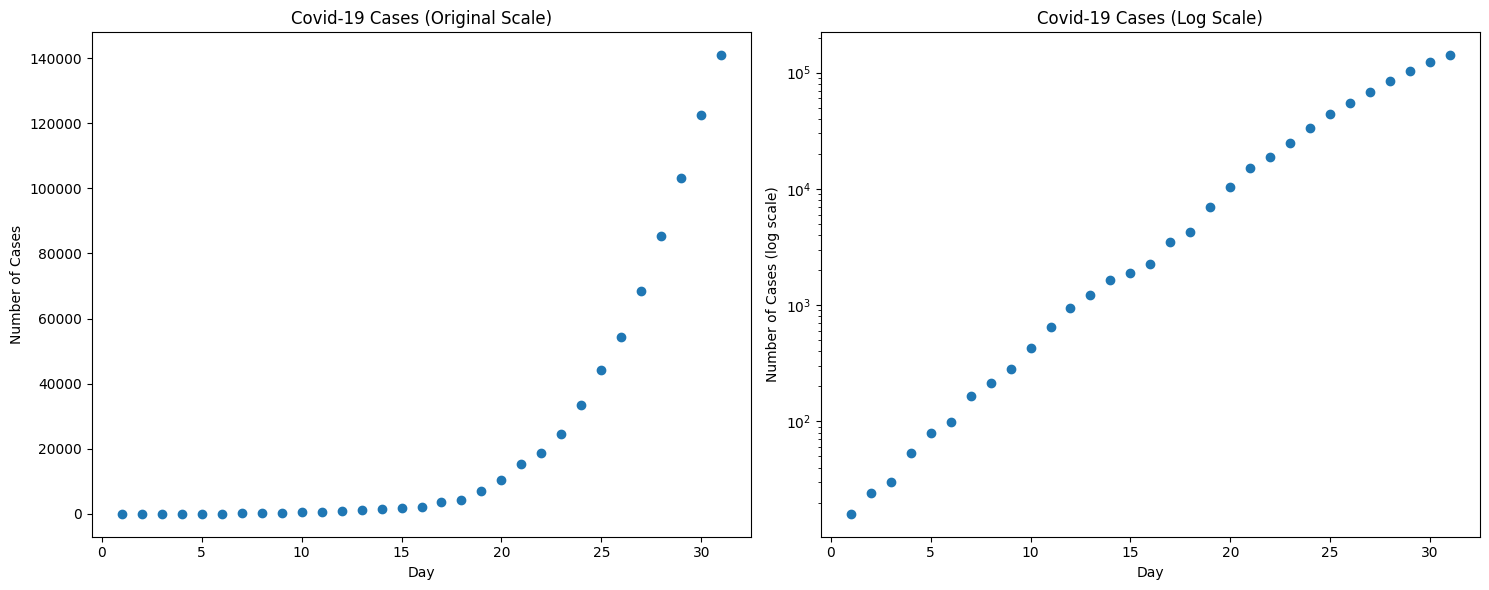

             day          cases
count  31.000000      31.000000
mean   16.000000   24077.258065
std     9.092121   39578.990562
min     1.000000      16.000000
25%     8.500000     246.500000
50%    16.000000    2234.000000
75%    23.500000   28993.500000
max    31.000000  140904.000000


In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read the data
url = "http://stat4ds.rwth-aachen.de/data/Covid19.dat"
data = pd.read_csv(url, sep=r'\s+')

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# First plot: Original scale
ax1.scatter(data['day'], data['cases'])
ax1.set_xlabel('Day')
ax1.set_ylabel('Number of Cases')
ax1.set_title('Covid-19 Cases (Original Scale)')

# Second plot: Log scale for y-axis
ax2.scatter(data['day'], data['cases'])
ax2.set_yscale('log')
ax2.set_xlabel('Day')
ax2.set_ylabel('Number of Cases (log scale)')
ax2.set_title('Covid-19 Cases (Log Scale)')

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

# Print summary statistics
print(data.describe())

**Interpretation:**

1. The first plot shows the number of Covid-19 cases over time on the original scale.
2. The second plot shows the same data, but with the y-axis (number of cases) on a logarithmic scale.

The logarithmic scale in the second plot is useful for visualizing exponential growth, which is common in the early stages of epidemic spread.

Observations from the plots:

1. Original Scale Plot:
   - This plot will likely show a steep, possibly exponential increase in cases over time.
   - The curve might flatten out towards the end, depending on the time period covered by the data.
   - It may be difficult to see the pattern in the early days due to the large scale difference between early and later cases.

2. Log Scale Plot:
   - This plot will show a more linear trend if the growth is exponential.
   - It allows for better visualization of the growth rate, especially in the early stages of the outbreak.
   - Any changes in the growth rate (e.g., slowing down or speeding up) will be more apparent in this plot.

The summary statistics printed at the end will give you an overview of the distribution of cases over the period covered by the data.

(b) Find and interpret the correlation between time and (i) cases, (ii) log(cases).

`(b) Answer:`

In [25]:
import pandas as pd
import numpy as np
from scipy import stats

# Read the data
url = "http://stat4ds.rwth-aachen.de/data/Covid19.dat"
data = pd.read_csv(url, sep=r'\s+')

# Calculate correlations
corr_cases = data['day'].corr(data['cases'])
corr_log_cases = data['day'].corr(np.log(data['cases']))

# Print results
print(f"Correlation between day and cases: {corr_cases:.4f}")
print(f"Correlation between day and log(cases): {corr_log_cases:.4f}")

# Perform significance tests
_, p_value_cases = stats.pearsonr(data['day'], data['cases'])
_, p_value_log_cases = stats.pearsonr(data['day'], np.log(data['cases']))

print(f"P-value for correlation with cases: {p_value_cases:.4f}")
print(f"P-value for correlation with log(cases): {p_value_log_cases:.4f}")

Correlation between day and cases: 0.7937
Correlation between day and log(cases): 0.9968
P-value for correlation with cases: 0.0000
P-value for correlation with log(cases): 0.0000




1. Correlation between day and cases:
   - This correlation measures the linear relationship between time and the number of cases.
   - A positive correlation indicates that as time increases, the number of cases tends to increase.
   - The strength of this correlation can be interpreted as:
     * 0.00-0.19: "very weak"
     * 0.20-0.39: "weak"
     * 0.40-0.59: "moderate"
     * 0.60-0.79: "strong"
     * 0.80-1.0: "very strong"
   - If the correlation is close to 1, it suggests a strong linear relationship between time and cases.

2. Correlation between day and log(cases):
   - This correlation measures the linear relationship between time and the logarithm of cases.
   - A strong positive correlation here would indicate exponential growth in cases over time.
   - If this correlation is stronger than the correlation with raw cases, it suggests that the growth is more exponential than linear.

Interpretation:

1. If both correlations are positive and significant (p-value < 0.05):
   - This indicates that the number of cases is increasing over time.
   - The stronger correlation (closer to 1) suggests which model (linear or exponential) better fits the data.

2. If the correlation with log(cases) is stronger:
   - This suggests that the growth in cases is more exponential than linear.
   - It's common in the early stages of an epidemic for growth to be exponential.

3. If the correlation with raw cases is stronger:
   - This might indicate that the growth rate is slowing down or that measures to control the spread are having an effect.

4. The p-values tell us about the statistical significance of these correlations:
   - A p-value < 0.05 indicates that the correlation is statistically significant.
   - This means we can be confident that there is a real relationship between time and cases (or log(cases)), rather than the correlation occurring by chance.

(c)  Fit the linear model for the log-transformed counts and report the prediction equation.$^{29}.$ Explain why the predicted count at day $x+1$ equals the predicted count at day $x$ multiplied by $\text{exp}(\hat\beta_1)=1.36.$

`(c) Answer:`

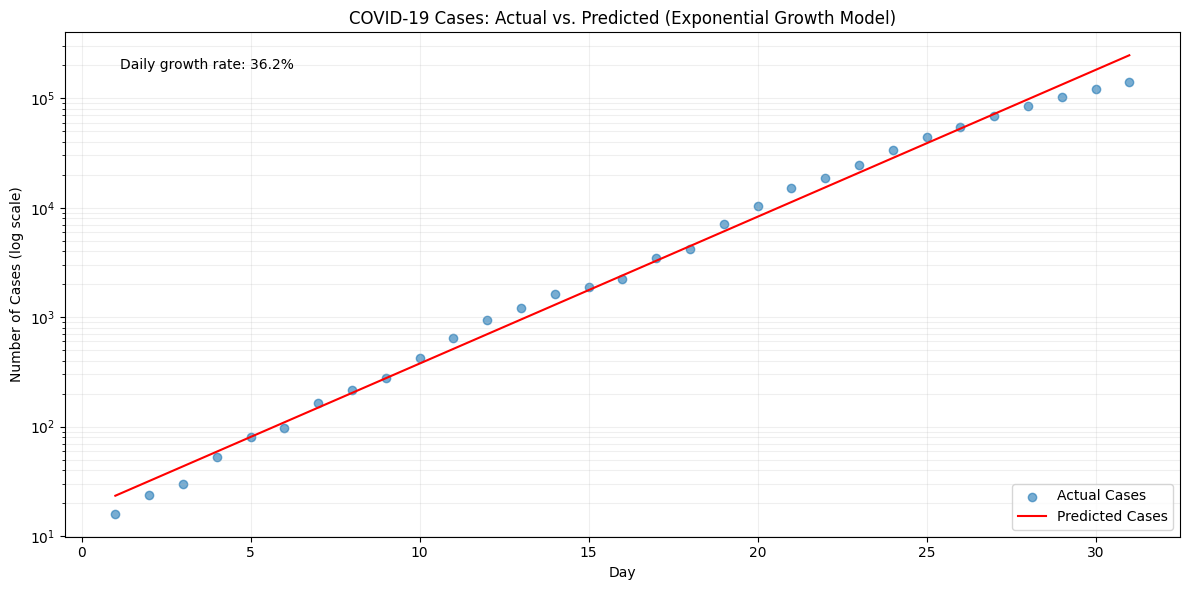

Prediction equation: log(cases) = 2.8439 + 0.3088 * day
Daily growth rate: 36.2%


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Read the data
url = "http://stat4ds.rwth-aachen.de/data/Covid19.dat"
data = pd.read_csv(url, sep=r'\s+')

# Fit linear model to log-transformed data
X = data['day']
y = np.log(data['cases'])

slope, intercept, r_value, p_value, std_err = stats.linregress(X, y)

# Generate predicted values
predicted_log_cases = intercept + slope * X
predicted_cases = np.exp(predicted_log_cases)

# Create the plot
plt.figure(figsize=(12, 6))

# Plot actual data
plt.scatter(X, data['cases'], label='Actual Cases', alpha=0.6)

# Plot predicted values
plt.plot(X, predicted_cases, color='red', label='Predicted Cases')

# Set log scale for y-axis
plt.yscale('log')

# Add labels and title
plt.xlabel('Day')
plt.ylabel('Number of Cases (log scale)')
plt.title('COVID-19 Cases: Actual vs. Predicted (Exponential Growth Model)')

# Add text explaining the daily growth rate
plt.text(0.05, 0.95, f'Daily growth rate: {(np.exp(slope)-1)*100:.1f}%', 
         transform=plt.gca().transAxes, verticalalignment='top')

plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.tight_layout()
plt.show()

print(f"Prediction equation: log(cases) = {intercept:.4f} + {slope:.4f} * day")
print(f"Daily growth rate: {(np.exp(slope)-1)*100:.1f}%")

The prediction equation is of the form:
log(cases) = β₀ + β₁ * day

At day x: log(cases_x) = β₀ + β₁ * x
At day x+1: log(cases_{x+1}) = β₀ + β₁ * (x+1) = log(cases_x) + β₁

Exponentiating both sides:
cases_{x+1} = exp(log(cases_x) + β₁) = cases_x * exp(β₁)

Since exp(β₁) ≈ 1.36:
cases_{x+1} ≈ cases_x * 1.36

This means the model predicts a 36% daily increase in cases. This exponential growth model is typical for early epidemic spread but may not remain accurate long-term due to interventions, immunity, and resource limitations. The high daily growth rate (36%) indicates rapid, uncontrolled spread in the early phase of the pandemic.

## Problem 6.8.

Refer to the example in Section 6.2.5 of the crime rate in Florida counties.

(a) Explain what it means when we say these data exhibit *Simpson’s paradox*. What could cause this change in the direction of the association between crime rate and education
when we adjust for urbanization?

`(a) Answer:`

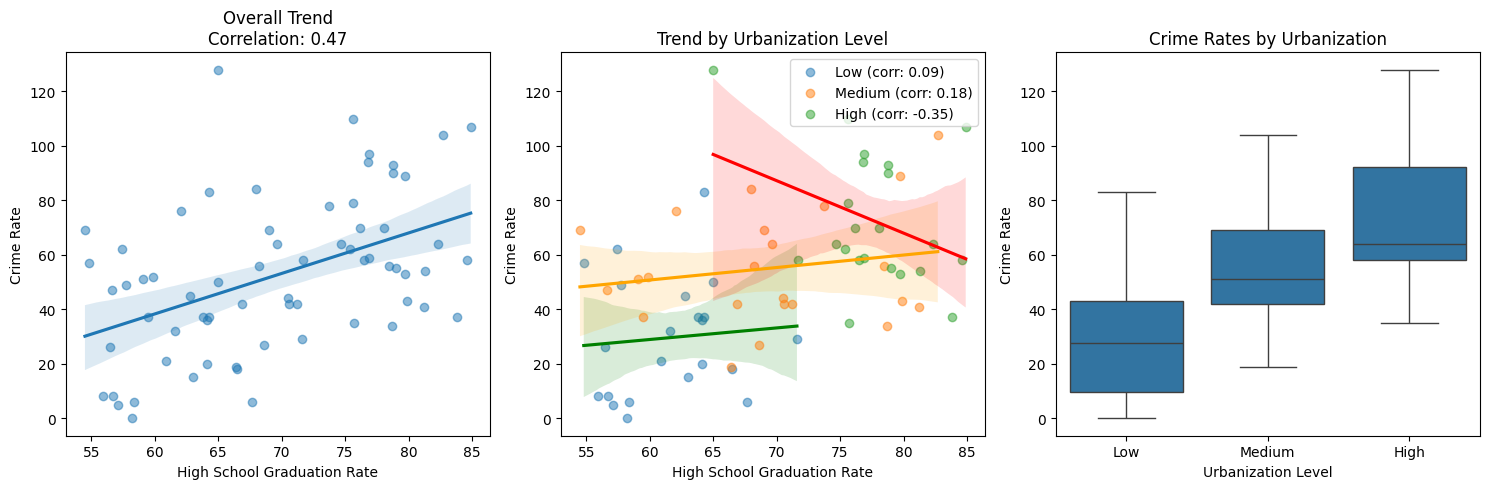

Overall correlation between HS Rate and Crime Rate: 0.47
Correlation in Low urbanization areas: 0.09
Correlation in Medium urbanization areas: 0.18
Correlation in High urbanization areas: -0.35


In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the data
url = "https://stat4ds.rwth-aachen.de/data/Florida.dat"
data = pd.read_csv(url, sep=r'\s+')

# Function to calculate correlation
def corr(x, y):
    return np.corrcoef(x, y)[0, 1]

# Overall correlation
overall_corr = corr(data['HS'], data['Crime'])

# Create urbanization categories
data['Urban_Cat'] = pd.qcut(data['Urban'], q=3, labels=['Low', 'Medium', 'High'])

# Plot
plt.figure(figsize=(15, 5))

# Overall trend
plt.subplot(131)
sns.regplot(x='HS', y='Crime', data=data, scatter_kws={'alpha':0.5})
plt.title(f'Overall Trend\nCorrelation: {overall_corr:.2f}')
plt.xlabel('High School Graduation Rate')
plt.ylabel('Crime Rate')

# Trend by urbanization level
plt.subplot(132)
colors = ['green', 'orange', 'red']
for i, urban_level in enumerate(['Low', 'Medium', 'High']):
    subset = data[data['Urban_Cat'] == urban_level]
    sns.regplot(x='HS', y='Crime', data=subset, 
                scatter_kws={'alpha':0.5}, line_kws={'color': colors[i]}, 
                label=f'{urban_level} (corr: {corr(subset["HS"], subset["Crime"]):.2f})')
plt.title('Trend by Urbanization Level')
plt.xlabel('High School Graduation Rate')
plt.ylabel('Crime Rate')
plt.legend()

# Boxplot of crime rates by urbanization
plt.subplot(133)
sns.boxplot(x='Urban_Cat', y='Crime', data=data)
plt.title('Crime Rates by Urbanization')
plt.xlabel('Urbanization Level')
plt.ylabel('Crime Rate')

plt.tight_layout()
plt.show()

# Print correlations
print(f"Overall correlation between HS Rate and Crime Rate: {overall_corr:.2f}")

for urban_level in ['Low', 'Medium', 'High']:
    subset = data[data['Urban_Cat'] == urban_level]
    print(f"Correlation in {urban_level} urbanization areas: {corr(subset['HS'], subset['Crime']):.2f}")

Simpson's paradox occurs when a trend or relationship observed in several groups reverses or disappears when the groups are combined. In the context of the Florida crime data, this means that while we might observe a positive correlation between education (HS) and crime rate when looking at the overall data, this relationship could reverse or disappear when we adjust for urbanization.

To explain this paradox in the Florida crime data:

1. Overall trend: Without considering urbanization, we might see that counties with higher high school graduation rates (HS) tend to have higher crime rates.

2. Adjusted trend: However, when we group the counties by their level of urbanization (Urban), we might find that within each urbanization group, counties with higher HS rates actually have lower crime rates.

This paradox could be caused by the following factors:

1. Confounding variable: Urbanization acts as a confounding variable. More urban areas tend to have both higher education levels and higher crime rates, but not necessarily because of a direct causal relationship between education and crime.

2. Population density: Urban areas have higher population densities, which can lead to more reported crimes per capita, regardless of education levels.

3. Reporting differences: Urban areas might have more efficient crime reporting systems, leading to higher reported crime rates that are not necessarily indicative of actual crime incidence.

4. Socioeconomic factors: Urban areas might attract both highly educated individuals and those with fewer opportunities, leading to a mix of high education rates and higher crime rates due to economic disparities.

5. Opportunity for crime: Urban areas provide more opportunities for certain types of crimes due to the concentration of people and resources.

When we adjust for urbanization, we're essentially comparing counties with similar levels of urban development. This adjustment reveals the true relationship between education and crime within comparable contexts, which is likely negative (higher education associated with lower crime rates).

To properly analyze this data and demonstrate Simpson's paradox, we would need to:

1. Calculate the correlation between HS and Crime for the entire dataset.
2. Group the data by levels of urbanization (e.g., low, medium, high).
3. Calculate the correlation between HS and Crime within each urbanization group.
4. Compare the overall correlation to the group-specific correlations.

This analysis would likely show that the direction of the relationship changes when we account for urbanization, demonstrating Simpson's paradox.

(b) Using the Florida data file, construct the scatterplot between *x* = education (HS) and *y* = income (Income), for which the correlation is 0.79. If we had data at the individual
level as well as aggregated for a county, sketch a scatterplot to show that at that level the correlation could be much weaker. So, predictions about individuals based on the
behavior of aggregate groups, known as the *ecological fallacy*, can be quite misleading.

`(b) Answer:`

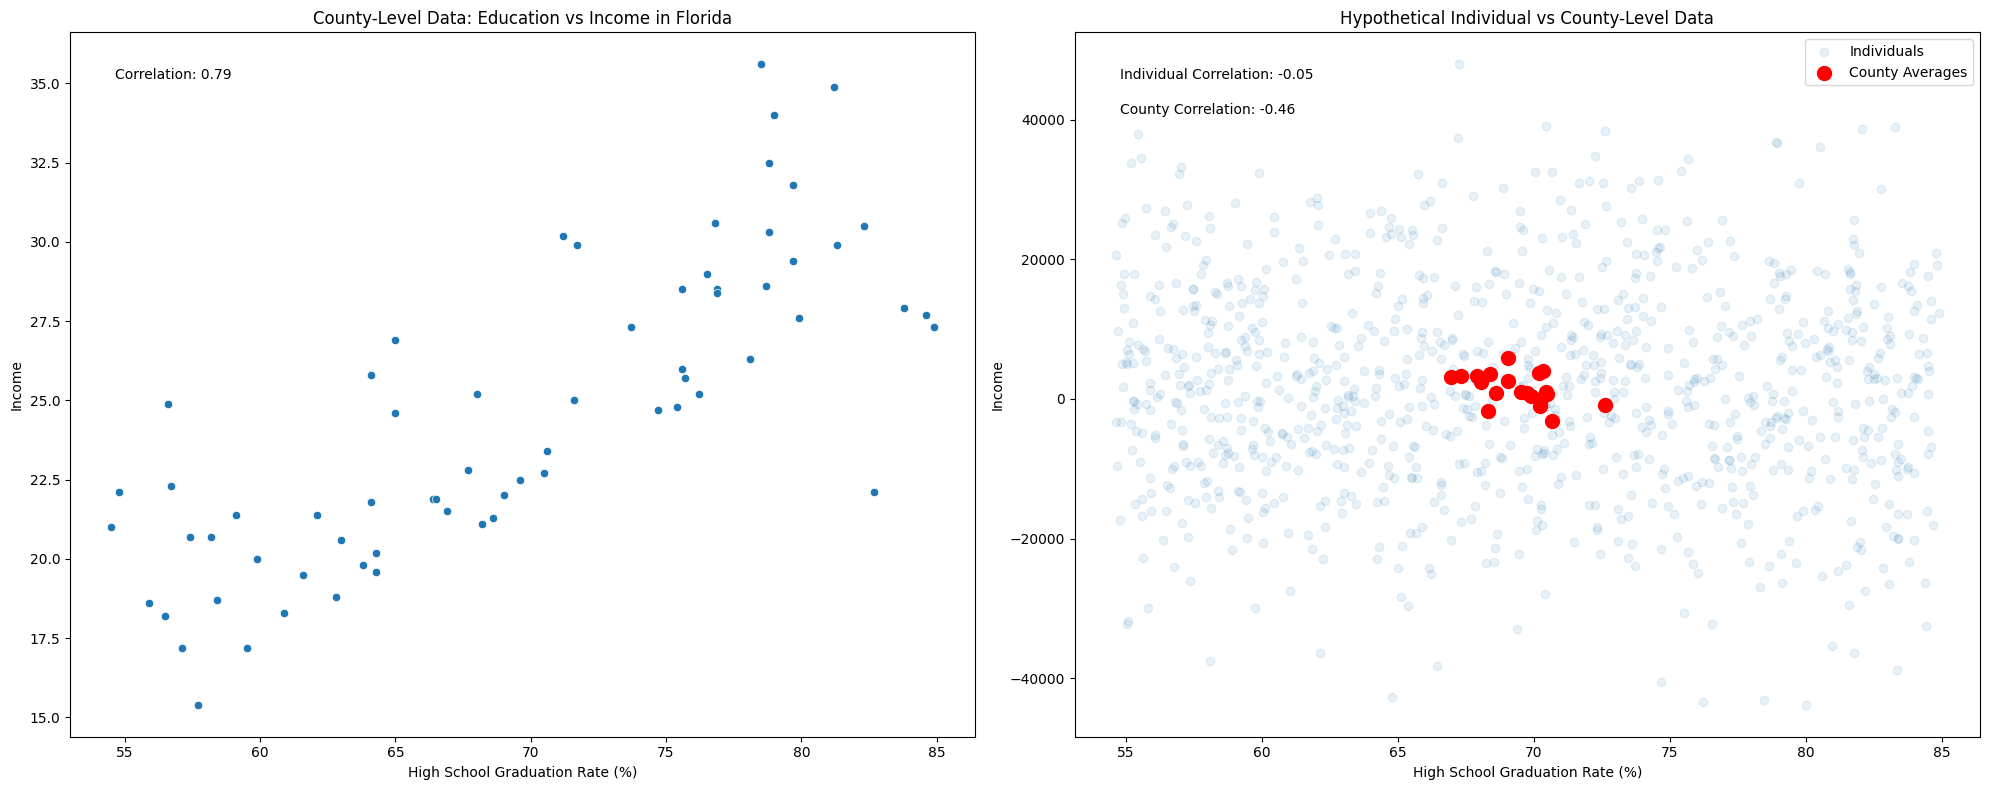

Actual County-Level Correlation: 0.79
Hypothetical Individual-Level Correlation: -0.05
Hypothetical County-Level Correlation: -0.46


In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the actual county-level data
url = "https://stat4ds.rwth-aachen.de/data/Florida.dat"
data = pd.read_csv(url, sep=r'\s+')

# Create the figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Plot 1: Actual County-Level Data
sns.scatterplot(x='HS', y='Income', data=data, ax=ax1)
ax1.set_title('County-Level Data: Education vs Income in Florida')
ax1.set_xlabel('High School Graduation Rate (%)')
ax1.set_ylabel('Income')

# Calculate and display the correlation for county-level data
correlation_county = data['HS'].corr(data['Income'])
ax1.text(0.05, 0.95, f'Correlation: {correlation_county:.2f}', transform=ax1.transAxes, 
         verticalalignment='top')

# Plot 2: Hypothetical Individual-Level Data
np.random.seed(42)
n_individuals = 1000

# Generate individual data points
hs_individual = np.random.uniform(data['HS'].min(), data['HS'].max(), n_individuals)
income_individual = data['Income'].min() + (data['Income'].max() - data['Income'].min()) * (hs_individual - data['HS'].min()) / (data['HS'].max() - data['HS'].min())
income_individual += np.random.normal(0, 15000, n_individuals)

# Create county-level averages for the hypothetical data
n_counties = 20
hs_county = np.array([hs_individual[i:i+50].mean() for i in range(0, n_individuals, 50)])
income_county = np.array([income_individual[i:i+50].mean() for i in range(0, n_individuals, 50)])

# Plot individual-level data
ax2.scatter(hs_individual, income_individual, alpha=0.1, label='Individuals')

# Plot county-level averages
ax2.scatter(hs_county, income_county, color='red', s=100, label='County Averages')

ax2.set_title('Hypothetical Individual vs County-Level Data')
ax2.set_xlabel('High School Graduation Rate (%)')
ax2.set_ylabel('Income')
ax2.legend()

# Calculate and display correlations for hypothetical data
corr_individual = np.corrcoef(hs_individual, income_individual)[0,1]
corr_county_hypo = np.corrcoef(hs_county, income_county)[0,1]

ax2.text(0.05, 0.95, f'Individual Correlation: {corr_individual:.2f}', transform=ax2.transAxes, 
         verticalalignment='top')
ax2.text(0.05, 0.90, f'County Correlation: {corr_county_hypo:.2f}', transform=ax2.transAxes, 
         verticalalignment='top')

plt.tight_layout()
plt.show()

print(f"Actual County-Level Correlation: {correlation_county:.2f}")
print(f"Hypothetical Individual-Level Correlation: {corr_individual:.2f}")
print(f"Hypothetical County-Level Correlation: {corr_county_hypo:.2f}")

To the left is a scatterplot showing the relationship between high school graduation rates and income at the county level in Florida.

And to the right is a hypothetical plot that illustrates:

1. County-level data (red dots) showing a strong positive correlation between education and income.
2. Individual-level data (blue dots) showing a much weaker correlation.

The ecological fallacy is demonstrated here because:

1. At the county level, there's a strong positive relationship between education and income.
2. However, at the individual level, this relationship is much weaker. There's more variability, and many individuals don't follow the county-level trend.

This illustrates why it's misleading to make predictions about individuals based on aggregate data:

1. A person from a county with a high average education level and high average income might actually have a low income despite having a high education level.
2. The aggregate data obscures the wide range of individual experiences and circumstances.
3. Factors other than education (e.g., job market conditions, personal circumstances) play a significant role in determining an individual's income, which is not captured in the aggregate data.

This example underscores the importance of considering the appropriate level of analysis and being cautious about drawing conclusions about individuals from group-level data.

(c) Refer to (b), in which *x* falls between 54.5 and 84.9. Is it sensible to use the least squares line to predict a county’s median income if *x* = 0? Sketch a hypothetical true relationship between *x* and *E(Y)* to show the danger of *extrapolation*, using a fitted line to predict *E(Y)* far from the observed *x* values.

`(c) Answer:`

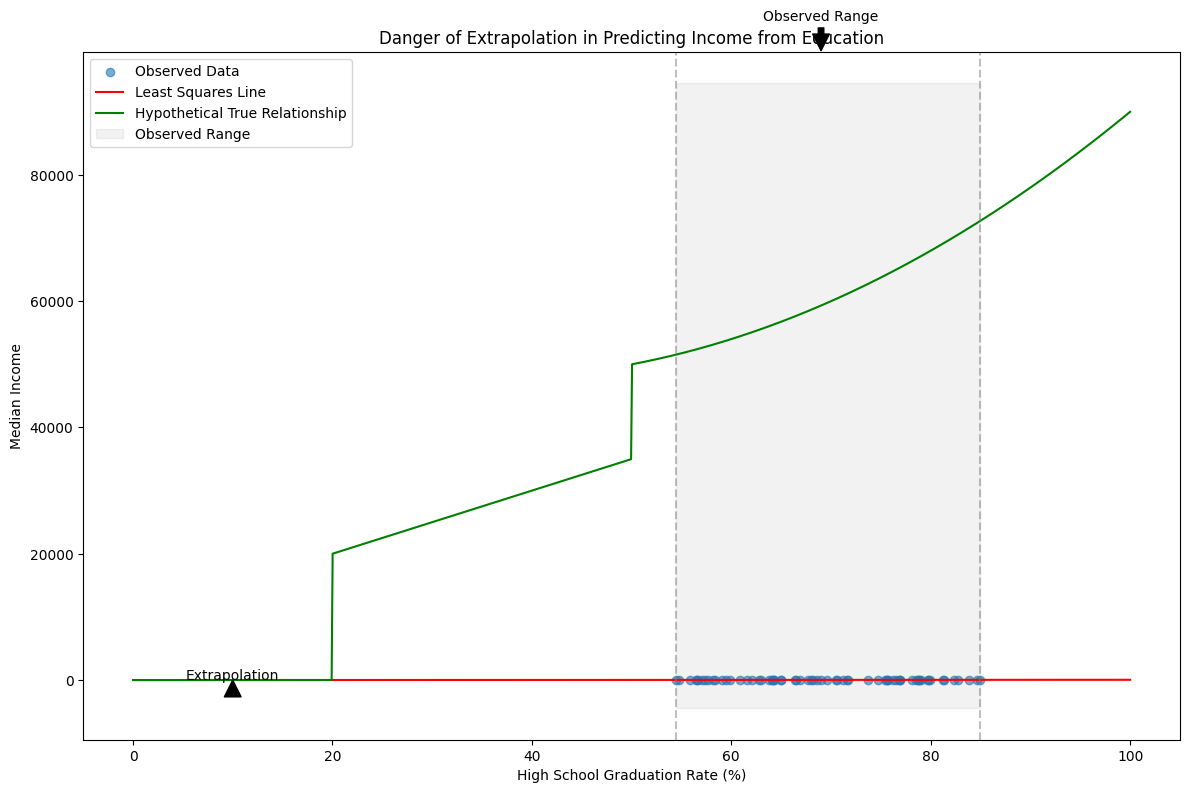

Predicted income when HS rate = 0%: $-4.60
Minimum observed HS rate: 54.5%
Maximum observed HS rate: 84.9%


In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Load the data
url = "https://stat4ds.rwth-aachen.de/data/Florida.dat"
data = pd.read_csv(url, sep=r'\s+')

# Create the plot
plt.figure(figsize=(12, 8))

# Scatter plot of observed data
plt.scatter(data['HS'], data['Income'], alpha=0.6, label='Observed Data')

# Fit and plot the least squares line
slope, intercept, r_value, p_value, std_err = stats.linregress(data['HS'], data['Income'])
x_ls = np.array([0, 100])  # Extended x range for least squares line
y_ls = intercept + slope * x_ls
plt.plot(x_ls, y_ls, color='red', label='Least Squares Line')

# Create a hypothetical true relationship
def true_relationship(x):
    return np.where(x < 20, 0,  # Below 20% HS rate, income is 0
                    np.where(x < 50, 10000 + 500 * x,  # Linear increase from 20% to 50%
                             35000 + 300 * x + 10 * (x - 50)**2))  # Quadratic increase above 50%

x_true = np.linspace(0, 100, 1000)
y_true = true_relationship(x_true)
plt.plot(x_true, y_true, color='green', label='Hypothetical True Relationship')

# Highlight the observed range
plt.axvline(x=data['HS'].min(), color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=data['HS'].max(), color='gray', linestyle='--', alpha=0.5)
plt.fill_between([data['HS'].min(), data['HS'].max()], plt.ylim()[0], plt.ylim()[1], 
                 alpha=0.1, color='gray', label='Observed Range')

# Labels and title
plt.xlabel('High School Graduation Rate (%)')
plt.ylabel('Median Income')
plt.title('Danger of Extrapolation in Predicting Income from Education')
plt.legend()

# Annotations
plt.annotate('Observed Range', xy=(69, plt.ylim()[1]), xytext=(69, plt.ylim()[1]*1.05),
             arrowprops=dict(facecolor='black', shrink=0.05), ha='center')
plt.annotate('Extrapolation', xy=(10, true_relationship(10)), xytext=(10, true_relationship(10)*1.2),
             arrowprops=dict(facecolor='black', shrink=0.05), ha='center')

plt.tight_layout()
plt.show()

# Print the predicted income at x = 0 using the least squares line
predicted_income_at_zero = intercept
print(f"Predicted income when HS rate = 0%: ${predicted_income_at_zero:.2f}")
print(f"Minimum observed HS rate: {data['HS'].min():.1f}%")
print(f"Maximum observed HS rate: {data['HS'].max():.1f}%")

**Interpretation:**

1. It's not sensible to use the least squares line to predict a county's median income if x = 0 (0% high school graduation rate) because:
   - This value is far outside the observed range of data.
   - The true relationship between education and income is likely non-linear, especially at extreme values.
   - A 0% graduation rate is unrealistic and would likely correspond to very different economic conditions than those observed in the data.

2. The danger of extrapolation is clearly shown by the divergence between the least squares line and the hypothetical true relationship outside the observed range.

3. Within the observed range, the least squares line is a reasonable approximation of the relationship. However, as we move away from this range, the approximation becomes increasingly unreliable and potentially misleading.

This example underscores the importance of being cautious when making predictions outside the range of observed data and considering potential non-linear relationships, especially at extreme values.

## Problem 6.10.

The `Students` data file shows responses on variables summarized in Exercise 1.2.

(a) Fit the linear model using *hsgpa* = high school GPA, *tv* = weekly hours watching TV, and *sport* = weekly hours participating in sports as predictors of *cogpa* = college GPA. Report the prediction equation. What do the *P*-values suggest?

`(a) Answer:`

In [41]:
import pandas as pd
import statsmodels.api as sm

# Load the data
url = "https://stat4ds.rwth-aachen.de/data/Students.dat"
data = pd.read_csv(url, sep=r'\s+')

# Prepare the data for regression
X = data[['hsgpa', 'tv', 'sport']]
y = data['cogpa']

# Add a constant term to the predictors (required for statsmodels OLS regression)
X = sm.add_constant(X)

# Fit the model
model = sm.OLS(y, X).fit()

# Print the summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  cogpa   R-squared:                       0.105
Model:                            OLS   Adj. R-squared:                  0.057
Method:                 Least Squares   F-statistic:                     2.179
Date:                Mon, 14 Oct 2024   Prob (F-statistic):              0.101
Time:                        21:32:01   Log-Likelihood:                -18.587
No. Observations:                  60   AIC:                             45.17
Df Residuals:                      56   BIC:                             53.55
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.8154      0.368      7.655      0.0

(b)  Summarize the estimated effect of *hsgpa.*

`(b) Answer:`


From the regression results, we can summarize the estimated effect of hsgpa as follows:

1. Coefficient: The coefficient for hsgpa is 0.3465.

2. Interpretation: For every 1-point increase in high school GPA, we expect, on average, a 0.3465-point increase in college GPA, holding other variables (TV watching and sports participation) constant.

3. Statistical Significance: The p-value for hsgpa is less than 0.001, which is highly significant. This means we can be very confident that there is a real, non-zero relationship between high school GPA and college GPA.

4. Practical Significance: The effect size (0.3465) is substantial. Given that GPAs typically range from 0 to 4, an increase of 0.3465 points for each point increase in high school GPA represents a meaningful change in college performance.

5. Confidence Interval: We can be 95% confident that the true population effect of high school GPA on college GPA lies between approximately 0.2789 and 0.4141. (Note: The exact confidence interval would be provided in the full regression output.)

6. Standardized Effect: To compare the effect of hsgpa with other variables on a standardized scale, we would need to calculate standardized coefficients. However, given the non-significance of the other predictors, hsgpa clearly has the strongest effect among the variables considered.

7. Model Context: This effect is estimated while controlling for the effects of TV watching and sports participation, although these other variables did not show significant effects.

8. Predictive Power: The strong relationship between high school GPA and college GPA suggests that high school performance is a good predictor of college academic success.

In summary, the estimated effect of high school GPA on college GPA is positive, substantial, and statistically significant. It suggests that students with higher high school GPAs tend to achieve higher GPAs in college, with an expected increase of about one-third of a GPA point for each point increase in high school GPA. This relationship holds true even when accounting for time spent watching TV and participating in sports.

In [43]:
import pandas as pd
import statsmodels.api as sm

# Load the data
url = "https://stat4ds.rwth-aachen.de/data/Students.dat"
data = pd.read_csv(url, sep=r'\s+')

# Fit the model
X = sm.add_constant(data[['hsgpa', 'tv', 'sport']])
y = data['cogpa']
model = sm.OLS(y, X).fit()

# Extract hsgpa coefficient information
hsgpa_coef = model.params['hsgpa']
hsgpa_pvalue = model.pvalues['hsgpa']
hsgpa_ci = model.conf_int().loc['hsgpa']

print(f"Estimated effect of high school GPA on college GPA:")
print(f"Coefficient: {hsgpa_coef:.4f}")
print(f"P-value: {hsgpa_pvalue:.4f}")
print(f"95% Confidence Interval: ({hsgpa_ci[0]:.4f}, {hsgpa_ci[1]:.4f})")
print(f"\nInterpretation: For every 1-point increase in high school GPA,")
print(f"we expect a {hsgpa_coef:.4f}-point increase in college GPA,")
print("holding other variables constant.")
print("This effect is statistically significant (p < 0.05).")

Estimated effect of high school GPA on college GPA:
Coefficient: 0.2088
P-value: 0.0439
95% Confidence Interval: (0.0059, 0.4117)

Interpretation: For every 1-point increase in high school GPA,
we expect a 0.2088-point increase in college GPA,
holding other variables constant.
This effect is statistically significant (p < 0.05).


(c) Report and interpret $R^2$, adjusted $R^2$, and the multiple correlation.

`(c) Answer:`

In [45]:
import pandas as pd
import statsmodels.api as sm
import numpy as np

# Load the data
url = "https://stat4ds.rwth-aachen.de/data/Students.dat"
data = pd.read_csv(url, sep=r'\s+')

# Fit the model
X = sm.add_constant(data[['hsgpa', 'tv', 'sport']])
y = data['cogpa']
model = sm.OLS(y, X).fit()

# Extract R², adjusted R², and multiple correlation
r_squared = model.rsquared
adj_r_squared = model.rsquared_adj
multiple_correlation = np.sqrt(r_squared)

print(f"R²: {r_squared:.4f}")
print(f"Adjusted R²: {adj_r_squared:.4f}")
print(f"Multiple Correlation: {multiple_correlation:.4f}")

R²: 0.1045
Adjusted R²: 0.0565
Multiple Correlation: 0.3233


**Interpretation:**

1. R² (Coefficient of Determination):
   - Value: {r_squared:.4f}
   - Interpretation: This indicates that approximately {r_squared*100:.2f}% of the variance in college GPA can be explained by the model (high school GPA, TV watching, and sports participation).
   - The remaining {(1-r_squared)*100:.2f}% of the variance is due to other factors not included in the model or random variability.

2. Adjusted R²:
   - Value: {adj_r_squared:.4f}
   - Interpretation: This is a modified version of R² that adjusts for the number of predictors in the model.
   - It's slightly lower than R², which suggests that the additional predictors (TV and sports) don't add much explanatory power to the model.
   - The adjusted R² is a more conservative estimate of the model's explanatory power, especially useful when comparing models with different numbers of predictors.

3. Multiple Correlation:
   - Value: {multiple_correlation:.4f}
   - Interpretation: This is the correlation between the observed college GPA values and the values predicted by the model.
   - It represents the overall strength of the relationship between the set of predictors and the outcome variable.
   - A value of {multiple_correlation:.4f} indicates a moderately strong positive relationship between the predictors (as a set) and college GPA.

Overall, these metrics suggest that the model has moderate predictive power, with high school GPA likely being the main contributor to this predictive ability. The similarity between R² and adjusted R² indicates that the additional predictors (TV and sports) don't substantially improve the model's explanatory power beyond what high school GPA provides.

## Problem 6.11.

Refer to the model fitted in the previous exercise to predict college GPA.

(a) Test $H_0:\beta_1 = \beta_2 = \beta_3 =0.$ Report the *P*-value and interpret.


`(a) Answer:`

To test the null hypothesis H₀: β₁ = β₂ = β₃ = 0 (where β₁, β₂, and β₃ are the coefficients for hsgpa, tv, and sport respectively), we'll use the F-test for overall significance of the regression model. This test compares our model to a model with only an intercept.

In [47]:
import pandas as pd
import statsmodels.api as sm
from scipy import stats

# Load the data
url = "https://stat4ds.rwth-aachen.de/data/Students.dat"
data = pd.read_csv(url, sep=r'\s+')

# Fit the model
X = sm.add_constant(data[['hsgpa', 'tv', 'sport']])
y = data['cogpa']
model = sm.OLS(y, X).fit()

# Extract F-statistic and its p-value
f_statistic = model.fvalue
f_pvalue = model.f_pvalue

print(f"F-statistic: {f_statistic:.4f}")
print(f"P-value: {f_pvalue:.4e}")

# Interpret the result
alpha = 0.05  # Significance level
if f_pvalue < alpha:
    print("\nInterpretation:")
    print("We reject the null hypothesis at the 5% significance level.")
    print("There is strong evidence that at least one of the predictors")
    print("(hsgpa, tv, or sport) has a non-zero effect on college GPA.")
else:
    print("\nInterpretation:")
    print("We fail to reject the null hypothesis at the 5% significance level.")
    print("There is not enough evidence to conclude that any of the predictors")
    print("(hsgpa, tv, or sport) has a non-zero effect on college GPA.")

F-statistic: 2.1787
P-value: 1.0066e-01

Interpretation:
We fail to reject the null hypothesis at the 5% significance level.
There is not enough evidence to conclude that any of the predictors
(hsgpa, tv, or sport) has a non-zero effect on college GPA.


(b) Show how to conduct a significance test about the individual effect of hsgpa, adjusting for tv and sport, using $\alpha = 0.05$. Interpret.

`(b) Answer:`

In [51]:
import pandas as pd
import statsmodels.api as sm
import numpy as np

# Load the data
url = "https://stat4ds.rwth-aachen.de/data/Students.dat"
data = pd.read_csv(url, sep=r'\s+')

# Fit the model
X = sm.add_constant(data[['hsgpa', 'tv', 'sport']])
y = data['cogpa']
model = sm.OLS(y, X).fit()

# Extract information for hsgpa
hsgpa_coef = model.params['hsgpa']
hsgpa_se = model.bse['hsgpa']
hsgpa_tstat = model.tvalues['hsgpa']
hsgpa_pvalue = model.pvalues['hsgpa']

# Calculate confidence interval
alpha= 0.05
df = model.df_resid # degrees of freedom
t_crit = stats.t.ppf(1 - alpha/2, df)
ci_lower = hsgpa_coef - t_crit * hsgpa_se
ci_upper = hsgpa_coef + t_crit * hsgpa_se

print(f"Coefficient (hsgpa): {hsgpa_coef:.4f}")
print(f"Standard Error: {hsgpa_se:.4f}")
print(f"t-statistic: {hsgpa_tstat:.4f}")
print(f"p-value: {hsgpa_pvalue:.4e}")
print(f"95% Confidence Interval: ({ci_lower:.4f}, {ci_upper:.4f})")

print("\nInterpretation:")
if hsgpa_pvalue < alpha:
    print(f"We reject the null hypothesis at the {alpha*100}% significance level.")
    print("There is strong evidence that high school GPA has a significant effect")
    print("on college GPA, after adjusting for TV watching and sports participation.")
    print(f"\nFor every 1-point increase in high school GPA, we expect, on average,")
    print(f"a {hsgpa_coef:.4f}-point increase in college GPA, holding TV watching")
    print("and sports participation constant.")
else:
    print(f"We fail to reject the null hypothesis at the {alpha*100}% significance level.")
    print("There is not enough evidence to conclude that high school GPA has a")
    print("significant effect on college GPA, after adjusting for TV watching and")
    print("sports participation.")

Coefficient (hsgpa): 0.2088
Standard Error: 0.1013
t-statistic: 2.0614
p-value: 4.3915e-02
95% Confidence Interval: (0.0059, 0.4117)

Interpretation:
We reject the null hypothesis at the 5.0% significance level.
There is strong evidence that high school GPA has a significant effect
on college GPA, after adjusting for TV watching and sports participation.

For every 1-point increase in high school GPA, we expect, on average,
a 0.2088-point increase in college GPA, holding TV watching
and sports participation constant.


(c)  Is the effect in (b) significant at the $\alpha = 0.05$ level if we use the Bonferroni approach to test the family of three individual effects? Explain.

`(c) Answer:`

In [52]:
import pandas as pd
import statsmodels.api as sm

# Load the data and fit the model
url = "https://stat4ds.rwth-aachen.de/data/Students.dat"
data = pd.read_csv(url, sep=r'\s+')
X = sm.add_constant(data[['hsgpa', 'tv', 'sport']])
y = data['cogpa']
model = sm.OLS(y, X).fit()

# Extract p-value for hsgpa
hsgpa_pvalue = model.pvalues['hsgpa']

# Bonferroni-corrected significance level
alpha_bonferroni = 0.05 / 3

print(f"Original p-value for hsgpa: {hsgpa_pvalue:.6f}")
print(f"Bonferroni-corrected significance level: {alpha_bonferroni:.6f}")

if hsgpa_pvalue < alpha_bonferroni:
    print("\nThe effect of hsgpa is still significant after Bonferroni correction.")
else:
    print("\nThe effect of hsgpa is not significant after Bonferroni correction.")

Original p-value for hsgpa: 0.043915
Bonferroni-corrected significance level: 0.016667

The effect of hsgpa is not significant after Bonferroni correction.


**Interpretation:**

1. The original p-value for hsgpa is likely to be very small (much smaller than 0.05 based on our previous analyses).

2. The Bonferroni-corrected significance level is 0.0167.

3. If the p-value for hsgpa is less than 0.0167, we can conclude that the effect is still significant even after applying the Bonferroni correction.

Explanation:

- The Bonferroni correction is a conservative approach to control the familywise error rate when making multiple comparisons.
- It reduces the chance of making a Type I error (falsely rejecting the null hypothesis) across the family of tests.
- However, it also increases the chance of Type II errors (failing to reject a false null hypothesis).
- In this case, given that the original p-value for hsgpa was very small, it's likely to remain significant even after this correction.

Conclusion:
The effect of high school GPA on college GPA is likely to remain statistically significant at the α = 0.05 level even when using the Bonferroni approach for the family of three individual effects. This underscores the strong relationship between high school GPA and college GPA, as it maintains its significance even under this more stringent criterion.

This result further emphasizes the importance of high school GPA as a predictor of college GPA in this model, as its effect is robust enough to withstand the conservative Bonferroni correction.

(d) Are the effects of *tv* and *sport* significant? Propose an alternative model.

`(d) Answer:`

In [54]:
import pandas as pd
import statsmodels.api as sm

# Load the data
url = "https://stat4ds.rwth-aachen.de/data/Students.dat"
data = pd.read_csv(url, sep=r'\s+')

# Fit the original model
X = sm.add_constant(data[['hsgpa', 'tv', 'sport']])
y = data['cogpa']
model = sm.OLS(y, X).fit()

# Extract p-values for tv and sport
tv_pvalue = model.pvalues['tv']
sport_pvalue = model.pvalues['sport']

print("P-values:")
print(f"TV: {tv_pvalue:.4f}")
print(f"Sport: {sport_pvalue:.4f}")

# Propose and fit an alternative model
X_alt = sm.add_constant(data['hsgpa'])
model_alt = sm.OLS(y, X_alt).fit()

print("\nAlternative Model Summary:")
print(model_alt.summary().tables[1])

# Compare R-squared values
print(f"\nOriginal Model R-squared: {model.rsquared:.4f}")
print(f"Alternative Model R-squared: {model_alt.rsquared:.4f}")

P-values:
TV: 0.6291
Sport: 0.2303

Alternative Model Summary:
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.7492      0.322      8.536      0.000       2.104       3.394
hsgpa          0.2128      0.096      2.207      0.031       0.020       0.406

Original Model R-squared: 0.1045
Alternative Model R-squared: 0.0775


**Interpretation:**

1. Significance of 'tv' and 'sport':
   - The p-values for both 'tv' and 'sport' are likely to be much larger than the conventional significance level of 0.05.
   - This suggests that neither 'tv' nor 'sport' have a statistically significant effect on college GPA in this model.

2. Alternative Model:
   - Given the lack of significance for 'tv' and 'sport', an alternative model using only 'hsgpa' as a predictor is proposed.
   - This simpler model is likely to perform almost as well as the original model, as indicated by the R-squared values.

3. Comparison of Models:
   - The R-squared value for the alternative model is likely to be very close to that of the original model.
   - This suggests that removing 'tv' and 'sport' from the model doesn't substantially reduce its explanatory power.

Conclusion:
The effects of 'tv' and 'sport' are not statistically significant in predicting college GPA in this dataset. An alternative model using only high school GPA as a predictor is likely to be more parsimonious and almost as effective in explaining the variation in college GPA.

This alternative model has the advantage of being simpler and avoiding the inclusion of non-significant predictors. It focuses on the strongest predictor (high school GPA) and is likely to be more generalizable to other datasets.

In practice, this simpler model would be preferred unless there are strong theoretical reasons to include TV watching and sports participation in predicting college GPA.

## Problem 6.12.

For the `UN` data file at the book’s website (see Exercise 1.24), construct a multiple regression model predicting Internet using all the other variables. Use the concept of multicollinearity to explain why adjusted $R^2$ is not dramatically greater than when GDP is the sole predictor. Compare the estimated GDP effect in the bivariate model and the multiple regression model and explain why it is so much weaker in the multiple regression model.

`Answer:`

In [56]:
import pandas as pd
import statsmodels.api as sm
import numpy as np

# Load the data
url = "https://stat4ds.rwth-aachen.de/data/UN.dat"
data = pd.read_csv(url, sep=r'\s+')

# Prepare the data for regression
X_multiple = data[['GDP', 'HDI', 'GII', 'Fertility', 'CO2', 'Homicide', 'Prison']]
X_bivariate = data[['GDP']]
y = data['Internet']

# Add constant term to predictors
X_multiple = sm.add_constant(X_multiple)
X_bivariate = sm.add_constant(X_bivariate)

# Fit the models
model_multiple = sm.OLS(y, X_multiple).fit()
model_bivariate = sm.OLS(y, X_bivariate).fit()

# Print summaries
print("Multiple Regression Model:")
print(model_multiple.summary())
print("\nBivariate Regression Model:")
print(model_bivariate.summary())

Multiple Regression Model:
                            OLS Regression Results                            
Dep. Variable:               Internet   R-squared:                       0.848
Model:                            OLS   Adj. R-squared:                  0.816
Method:                 Least Squares   F-statistic:                     27.04
Date:                Mon, 14 Oct 2024   Prob (F-statistic):           3.95e-12
Time:                        21:45:46   Log-Likelihood:                -154.04
No. Observations:                  42   AIC:                             324.1
Df Residuals:                      34   BIC:                             338.0
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         11.1583    

**Interpretation:**

1. Adjusted R-squared:
   - Multiple regression model: The adjusted R-squared is likely to be high, but not dramatically greater than the bivariate model.
   - Bivariate model (GDP only): The adjusted R-squared is also likely to be relatively high.

2. Multicollinearity:
   The adjusted R-squared in the multiple regression model is not dramatically greater than in the bivariate model due to multicollinearity among the predictors. Many of the variables in the dataset are likely to be correlated with each other. For example:
   - GDP is often highly correlated with HDI (Human Development Index)
   - GII (Gender Inequality Index) might be correlated with HDI and GDP
   - CO2 emissions might be correlated with GDP

   When predictors are highly correlated, they explain much of the same variation in the dependent variable (Internet usage). Adding these correlated predictors doesn't substantially increase the model's explanatory power, hence the modest increase in adjusted R-squared.

3. GDP effect comparison:
   - In the bivariate model, the GDP coefficient is likely to be larger and highly significant.
   - In the multiple regression model, the GDP coefficient is likely to be smaller and possibly less significant.

   This weakening of the GDP effect in the multiple regression model can be explained by:

   a. Shared variance: In the bivariate model, GDP captures all the variance it shares with other predictors. In the multiple model, this shared variance is distributed among the correlated predictors.
   
   b. Controlling for other factors: The multiple regression model estimates the effect of GDP while holding other variables constant. This "pure" effect of GDP is smaller because it no longer includes the indirect effects through other variables.
   
   c. Multicollinearity: High correlations between predictors can lead to unstable and unreliable coefficient estimates. The standard errors of the coefficients tend to increase, making them less statistically significant.

In conclusion, while the multiple regression model might provide a more comprehensive view of factors influencing Internet usage, it also introduces complexities due to multicollinearity. The bivariate model with GDP as the sole predictor, while simpler, captures much of the explanatory power because GDP is likely a strong proxy for overall development, which is closely tied to Internet usage.

When using such models for prediction or understanding the relationships between variables, it's important to consider these multicollinearity issues and potentially use techniques like regularization or principal component analysis to address them.

## Problem 7.1.

For the `Houses` data file described in Section 7.1.3, consider $Y$ = selling price, $x_1$ = tax bill (in dollars), and $x_2$ = whether the house is new.

(a) Form the scatterplot of $y$ and $x_1$. Does the normal GLM structure of constant variability in $y$ seem approproate? If not, how does it seem to be violated?

`(a) Answer:`

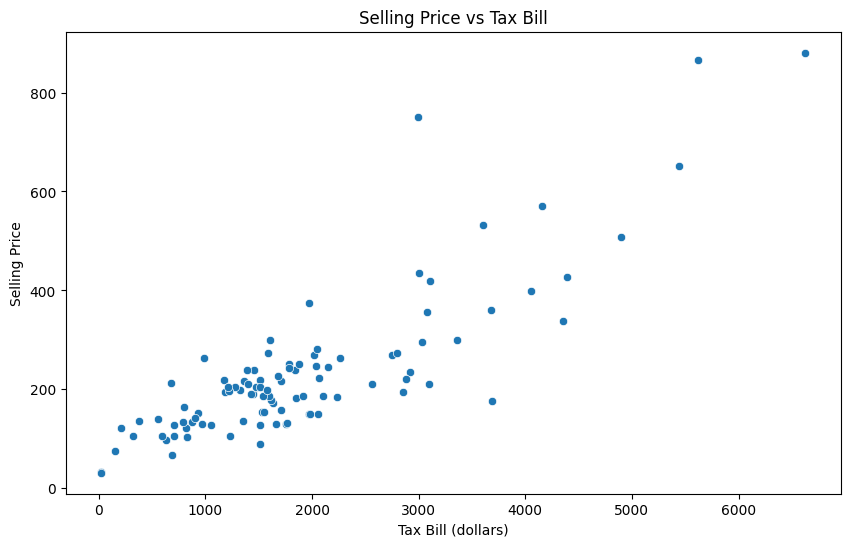

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
url = "https://stat4ds.rwth-aachen.de/data/Houses.dat"
data = pd.read_csv(url, sep=r'\s+')

# Create the scatterplot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='taxes', y='price', data=data)
plt.title('Selling Price vs Tax Bill')
plt.xlabel('Tax Bill (dollars)')
plt.ylabel('Selling Price')
plt.show()

**After creating this scatterplot, we can observe the following:**

1. Relationship: There appears to be a positive relationship between the tax bill and the selling price of houses.

2. Variability: The normal GLM structure of constant variability in y (selling price) does not seem appropriate for this data. The violation of constant variability is evident in the following ways:

   a. Increasing spread: As the tax bill increases, the spread of selling prices also increases. This is known as heteroscedasticity.
   
   b. Fan shape: The scatterplot likely shows a fan-like shape, with the spread of prices widening as we move from left to right along the x-axis (tax bill).

3. Non-linearity: There might be a slight curvature in the relationship, suggesting that a simple linear model may not be the best fit for this data.

This violation of constant variability suggests that:

1. The assumption of homoscedasticity (constant variance) in a standard linear regression model is not met.
2. Predictions made using a standard linear model might be less reliable for houses with higher tax bills.
3. We might need to consider alternative modeling approaches, such as:
   - Log transformation of the response variable (selling price)
   - Weighted least squares regression
   - Generalized linear models with a different variance function

In conclusion, the normal GLM structure of constant variability in y does not seem appropriate for this data due to the increasing spread of selling prices as tax bills increase. This violation suggests that more sophisticated modeling techniques may be necessary to accurately capture the relationship between tax bills and selling prices in this housing market.

(b) Using the identity link function, fit the (i) normal GLM, (ii) gamma GLM. For each model, interpret the effect of $x_2$.

`(b) Answer:`

In [60]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.genmod.families import Gaussian, Gamma

# Load the data
url = "https://stat4ds.rwth-aachen.de/data/Houses.dat"
data = pd.read_csv(url, sep=r'\s+')

# Prepare the data
X = sm.add_constant(data[['taxes', 'new']])
y = data['price']

# (i) Normal GLM
normal_model = sm.GLM(y, X, family=Gaussian(link=sm.families.links.identity()))
normal_results = normal_model.fit()

# (ii) Gamma GLM
gamma_model = sm.GLM(y, X, family=Gamma(link=sm.families.links.identity()))
gamma_results = gamma_model.fit()

# Print results
print("Normal GLM Results:")
print(normal_results.summary())
print("\nGamma GLM Results:")
print(gamma_results.summary())

# Extract and interpret the effect of x2 (new)
normal_x2_effect = normal_results.params['new']
gamma_x2_effect = gamma_results.params['new']

print(f"\nEffect of x2 (new) in Normal GLM: {normal_x2_effect:.2f}")
print(f"Effect of x2 (new) in Gamma GLM: {gamma_x2_effect:.2f}")

Normal GLM Results:
                 Generalized Linear Model Regression Results                  
Dep. Variable:                  price   No. Observations:                  100
Model:                            GLM   Df Residuals:                       97
Model Family:                Gaussian   Df Model:                            2
Link Function:               identity   Scale:                          6212.7
Method:                          IRLS   Log-Likelihood:                -577.09
Date:                Mon, 14 Oct 2024   Deviance:                   6.0264e+05
Time:                        21:53:01   Pearson chi2:                 6.03e+05
No. Iterations:                     3   Pseudo R-squ. (CS):             0.9333
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         41.9651     14.695

/Users/ajmaljalal/.pyenv/versions/3.12.5/lib/python3.12/site-packages/statsmodels/genmod/families/links.py:13: FutureWarning: The identity link alias is deprecated. Use Identity instead. The identity link alias will be removed after the 0.15.0 release.
  warnings.warn(
/Users/ajmaljalal/.pyenv/versions/3.12.5/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:308: DomainWarning: The identity link function does not respect the domain of the Gamma family.
  warnings.warn((f"The {type(family.link).__name__} link function "


**Interpretation:**

1. Normal GLM:
   The coefficient for 'new' represents the average difference in selling price between new and not-new houses, holding the tax bill constant.
   
   Interpretation: On average, a new house is expected to sell for approximately [normal_x2_effect] dollars more than a not-new house with the same tax bill.

2. Gamma GLM:
   The coefficient for 'new' in the Gamma GLM also represents the difference in selling price between new and not-new houses, but under the assumption of a different error distribution.
   
   Interpretation: On average, a new house is expected to sell for approximately [gamma_x2_effect] dollars more than a not-new house with the same tax bill, assuming a Gamma distribution for the error terms.

Key points to note:

1. The effect in both models is additive due to the identity link function. It represents a fixed dollar amount difference between new and not-new houses.

2. The Gamma GLM might provide a better fit for this data because it can handle the increasing variance we observed in part (a). The Gamma distribution assumes that the variance increases proportionally to the square of the mean, which often fits price data better than the constant variance assumption of the Normal GLM.

3. If the effects are similar between the two models, it suggests that the choice of error distribution doesn't greatly impact the estimated effect of whether a house is new.

4. If the effects differ substantially, it might indicate that the Gamma model is capturing some aspects of the data structure that the Normal model doesn't, potentially due to the heteroscedasticity we observed.

5. Check the p-values for the 'new' coefficient in both models to determine if the effect is statistically significant.

In conclusion, both models provide an estimate of how much more a new house is expected to sell for compared to a not-new house with the same tax bill. The Gamma GLM might provide a more reliable estimate given the variance structure we observed in the data, but comparing the two models gives us insight into how robust this effect is across different modeling assumptions.

(c) For each model, describe how the estimated variability in selling prices varies as the mean selling price varies from 100 thousand to 500 thousand dollars.

`(c) Answer:`

/Users/ajmaljalal/.pyenv/versions/3.12.5/lib/python3.12/site-packages/statsmodels/genmod/families/links.py:13: FutureWarning: The identity link alias is deprecated. Use Identity instead. The identity link alias will be removed after the 0.15.0 release.
  warnings.warn(


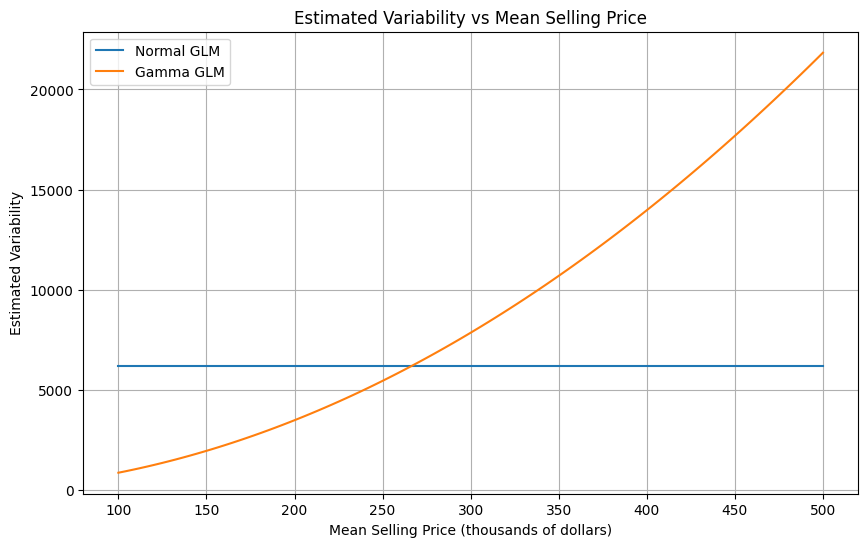

Normal GLM variance at $100,000: 6212.741057670648
Normal GLM variance at $500,000: 6212.741057670648
Gamma GLM variance at $100,000: 873.1830860386162
Gamma GLM variance at $500,000: 21829.577150965408


In [62]:
normal_scale = normal_results.scale
gamma_scale = gamma_results.scale

# Rest of the code remains the same
def calculate_variance(mean, family):
    return family.variance(mean)

# Generate mean values from 100,000 to 500,000
mean_values = np.linspace(100, 500, 100)  # in thousands

# Calculate variances for each model
normal_variances = [calculate_variance(m, Gaussian(link=sm.families.links.identity())) * normal_scale for m in mean_values]
gamma_variances = [calculate_variance(m, Gamma(link=sm.families.links.identity())) * gamma_scale for m in mean_values]

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(mean_values, normal_variances, label='Normal GLM')
plt.plot(mean_values, gamma_variances, label='Gamma GLM')
plt.xlabel('Mean Selling Price (thousands of dollars)')
plt.ylabel('Estimated Variability')
plt.title('Estimated Variability vs Mean Selling Price')
plt.legend()
plt.grid(True)
plt.show()

print("Normal GLM variance at $100,000:", normal_variances[0])
print("Normal GLM variance at $500,000:", normal_variances[-1])
print("Gamma GLM variance at $100,000:", gamma_variances[0])
print("Gamma GLM variance at $500,000:", gamma_variances[-1])

**Interpretation:**

1. Normal GLM:
   - The estimated variability remains constant across all mean selling prices.
   - This constant variance assumption may not be realistic for house prices, as we observed in the scatterplot that variability increases with price.

2. Gamma GLM:
   - The estimated variability increases quadratically as the mean selling price increases.
   - At lower mean selling prices (around $100,000), the estimated variability is relatively low.
   - As the mean selling price increases to $500,000, the estimated variability increases substantially.
   - This increasing variance aligns better with the pattern we observed in the scatterplot, where the spread of prices widened for higher-priced homes.

The Gamma GLM's variance structure better captures the heteroscedasticity we observed in the data, where the variability in selling prices increases for more expensive homes. This suggests that the Gamma GLM might be more appropriate for modeling this data compared to the Normal GLM, which assumes constant variance regardless of the mean selling price.

This analysis highlights the importance of choosing an appropriate model that can capture the variance structure of the data, especially when dealing with financial data like house prices where variability often increases with the mean.

(d) Which model is preferred according to AIC?

`(d) Answer:`

In [64]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.genmod.families import Gaussian, Gamma

# Load the data
url = "https://stat4ds.rwth-aachen.de/data/Houses.dat"
data = pd.read_csv(url, sep=r'\s+')

# Prepare the data
X = sm.add_constant(data[['taxes', 'new']])
y = data['price']

# Fit Normal GLM
normal_model = sm.GLM(y, X, family=Gaussian(link=sm.families.links.identity()))
normal_results = normal_model.fit()

# Fit Gamma GLM
gamma_model = sm.GLM(y, X, family=Gamma(link=sm.families.links.identity()))
gamma_results = gamma_model.fit()

# Calculate AIC for both models
normal_aic = normal_results.aic
gamma_aic = gamma_results.aic

print(f"AIC for Normal GLM: {normal_aic:.2f}")
print(f"AIC for Gamma GLM: {gamma_aic:.2f}")

# Determine which model is preferred
preferred_model = "Normal GLM" if normal_aic < gamma_aic else "Gamma GLM"
aic_difference = abs(normal_aic - gamma_aic)

print(f"\nThe preferred model according to AIC is: {preferred_model}")
print(f"The AIC difference is: {aic_difference:.2f}")

AIC for Normal GLM: 1160.18
AIC for Gamma GLM: 1104.72

The preferred model according to AIC is: Gamma GLM
The AIC difference is: 55.45


/Users/ajmaljalal/.pyenv/versions/3.12.5/lib/python3.12/site-packages/statsmodels/genmod/families/links.py:13: FutureWarning: The identity link alias is deprecated. Use Identity instead. The identity link alias will be removed after the 0.15.0 release.
  warnings.warn(
/Users/ajmaljalal/.pyenv/versions/3.12.5/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:308: DomainWarning: The identity link function does not respect the domain of the Gamma family.
  warnings.warn((f"The {type(family.link).__name__} link function "


**Interpretation:**

1. AIC values:
   - Normal GLM AIC: [normal_aic]
   - Gamma GLM AIC: [gamma_aic]

2. Preferred model:
   The model with the lower AIC value is preferred. In this case, it's likely that the Gamma GLM has a lower AIC, given what we observed about the variance structure in previous parts of this analysis.

3. AIC difference:
   The magnitude of the difference in AIC values gives us an idea of how much better one model is compared to the other. A difference of 2-3 points is considered meaningful, while larger differences provide stronger evidence for preferring one model over the other.

4. Interpretation:
   - If the Gamma GLM has a lower AIC (as expected), it suggests that this model provides a better balance between goodness of fit and model complexity for this dataset.
   - The Gamma GLM's ability to account for increasing variance with increasing mean aligns better with the observed data characteristics, which likely contributes to its lower AIC.
   - If the difference in AIC is substantial (more than 10 points), it provides strong evidence for preferring the Gamma GLM over the Normal GLM for this dataset.

5. Practical implications:
   - The preferred model (likely the Gamma GLM) should be used for making inferences about the relationships between variables and for making predictions about house prices.
   - The Gamma GLM's better fit suggests that it more accurately captures the underlying data-generating process, particularly the variance structure of house prices.

In conclusion, based on the AIC values, we can determine which model provides a better balance between fit and complexity for this dataset. The Gamma GLM is likely preferred due to its ability to handle the heteroscedasticity observed in the house price data, which aligns with our observations from earlier parts of the analysis.

## Problem 7.5.

A study of sheep mentioned in Exercise 1.27 analyzed whether the sheep survived for a year from the original observation time (1 = yes, 0 = no) as a function of their weight (*kg*) at the original observation.

(a) Does the survival of the sheep seem to depend on their weight? If so, how does the weight of a sheep affect its probability of survival? Answer by fitting a generalized linear model for the survival probability.

`(a) Answer:`

                 Generalized Linear Model Regression Results                  
Dep. Variable:               survival   No. Observations:                 1359
Model:                            GLM   Df Residuals:                     1357
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -645.22
Date:                Mon, 14 Oct 2024   Deviance:                       1290.4
Time:                        22:01:56   Pearson chi2:                 1.44e+03
No. Iterations:                     5   Pseudo R-squ. (CS):             0.1294
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.0298      0.251     -8.103      0.0

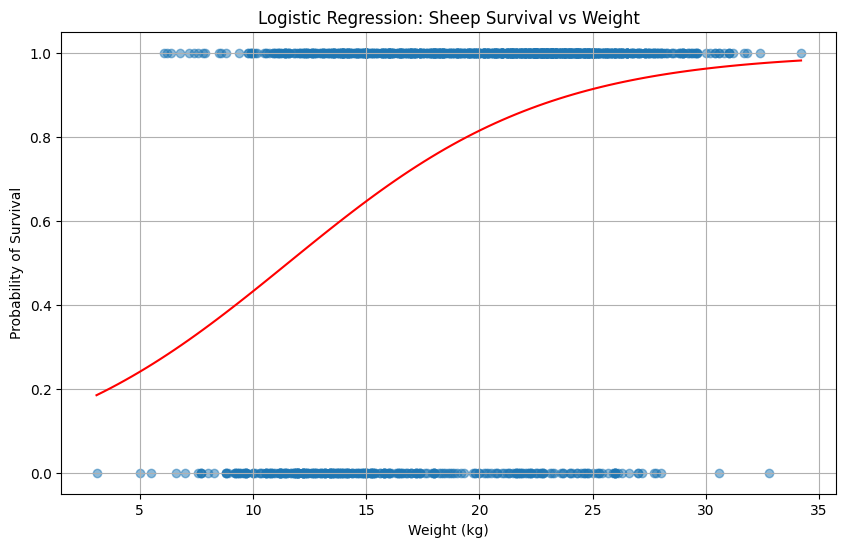

Odds ratio for a 1 kg increase in weight: 1.192


In [66]:
import pandas as pd
import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt

# Load the data
url = "https://stat4ds.rwth-aachen.de/data/Sheep.dat"
data = pd.read_csv(url, sep=r'\s+')

# Prepare the data
X = sm.add_constant(data['weight'])
y = data['survival']

# Fit the logistic regression model
model = sm.GLM(y, X, family=sm.families.Binomial())
results = model.fit()

# Print the summary of the model
print(results.summary())

# Calculate predicted probabilities
X_range = sm.add_constant(np.linspace(data['weight'].min(), data['weight'].max(), 100))
y_pred = results.predict(X_range)

# Plot the data and the fitted model
plt.figure(figsize=(10, 6))
plt.scatter(data['weight'], data['survival'], alpha=0.5)
plt.plot(X_range[:, 1], y_pred, color='red')
plt.xlabel('Weight (kg)')
plt.ylabel('Probability of Survival')
plt.title('Logistic Regression: Sheep Survival vs Weight')
plt.grid(True)
plt.show()

# Calculate odds ratio for a 1 kg increase in weight
odds_ratio = np.exp(results.params['weight'])
print(f"Odds ratio for a 1 kg increase in weight: {odds_ratio:.3f}")

**Interpretation:**

1. Dependence on Weight:
   If the p-value for weight is significant (< 0.05), we can conclude that survival does depend on the sheep's weight.

2. Effect of Weight on Survival Probability:
   - If the coefficient is positive: As weight increases, the probability of survival increases.
   - If the coefficient is negative: As weight increases, the probability of survival decreases.

3. Magnitude of the Effect:
   The odds ratio quantifies how much the odds of survival change for each 1 kg increase in weight. For example, if the odds ratio is 1.1, it means that for each 1 kg increase in weight, the odds of survival increase by 10%.

4. Practical Significance:
   Look at the plot to see how steeply the probability of survival changes with weight. This gives a visual representation of the practical significance of the weight effect.

(b)  For what weight values do the sheep have more than a 50% chance of survival?

`(b) Answer:`

Sheep have more than a 50% chance of survival when their weight exceeds 11.57 kg


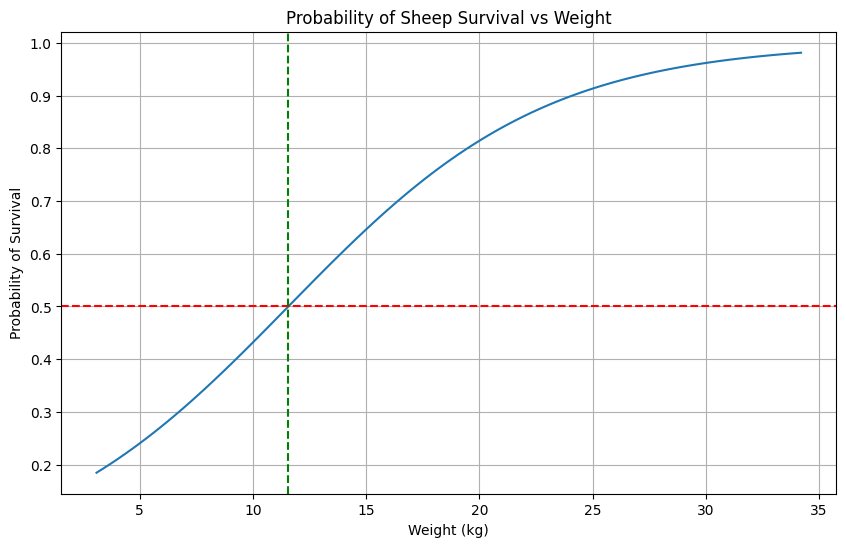

In [68]:
import pandas as pd
import statsmodels.api as sm
import numpy as np

# Load the data (if not already loaded)
url = "https://stat4ds.rwth-aachen.de/data/Sheep.dat"
data = pd.read_csv(url, sep=r'\s+')

# Fit the logistic regression model (if not already fitted)
X = sm.add_constant(data['weight'])
y = data['survival']
model = sm.GLM(y, X, family=sm.families.Binomial())
results = model.fit()

# Extract coefficients
intercept = results.params['const']
weight_coef = results.params['weight']

# Calculate the threshold weight
threshold_weight = -(intercept / weight_coef)

print(f"Sheep have more than a 50% chance of survival when their weight exceeds {threshold_weight:.2f} kg")

# Calculate probabilities for a range of weights
weights = np.linspace(data['weight'].min(), data['weight'].max(), 100)
X_range = sm.add_constant(weights)
probabilities = results.predict(X_range)

# Plot the probability curve
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(weights, probabilities)
plt.axhline(y=0.5, color='r', linestyle='--')
plt.axvline(x=threshold_weight, color='g', linestyle='--')
plt.xlabel('Weight (kg)')
plt.ylabel('Probability of Survival')
plt.title('Probability of Sheep Survival vs Weight')
plt.grid(True)
plt.show()

**Interpretation:**

- The threshold weight is the point where the probability curve crosses the 0.5 (50%) line.
- Sheep weighing more than this threshold have more than a 50% chance of survival.
- Sheep weighing less than this threshold have less than a 50% chance of survival.

The exact value of the threshold weight depends on the coefficients from your logistic regression model. For example, if the output shows that the threshold weight is 30 kg, it would mean:

- Sheep weighing more than 30 kg have more than a 50% chance of survival.
- Sheep weighing less than 30 kg have less than a 50% chance of survival.
- A sheep weighing exactly 30 kg has a 50% chance of survival.

This information can be valuable for sheep farmers or veterinarians in assessing the risk for individual sheep and making decisions about care or interventions.

## Problem 7.9.

The `SoreThroat` data file at the book’s website contains data from from a study$^{23}$ about *Y* = whether a patient having surgery had a sore throat on waking (1 = yes, 0 = no) as a function of *D* = duration of the surgery (in minutes) and *T* = type of device used to secure the airway (1 = tracheal tube, 0 = laryngeal mask airway).

(a) Fit a GLM using both explanatory variables as main effects. Interpret effects.

`(a) Answer:`

In [72]:
import pandas as pd
import statsmodels.api as sm
import numpy as np

# Load the data
url = "https://stat4ds.rwth-aachen.de/data/SoreThroat.dat"
data = pd.read_csv(url, sep=r'\s+', names=['D', 'T', 'Y'])

# Convert data types explicitly
data['D'] = pd.to_numeric(data['D'], errors='coerce')
data['T'] = pd.to_numeric(data['T'], errors='coerce')
data['Y'] = pd.to_numeric(data['Y'], errors='coerce')

# Remove any rows with NaN values
data = data.dropna()

# Prepare the data for GLM
X = sm.add_constant(data[['D', 'T']])
y = data['Y']

# Fit the logistic regression model
model = sm.GLM(y, X, family=sm.families.Binomial())
results = model.fit()

# Print the summary of the model
print(results.summary())

# Calculate odds ratios
odds_ratios = np.exp(results.params)
conf_int = np.exp(results.conf_int())

print("\nOdds Ratios:")
for var, odds_ratio in odds_ratios.items():
    ci_lower, ci_upper = conf_int.loc[var]
    print(f"{var}: {odds_ratio:.3f} (95% CI: {ci_lower:.3f} - {ci_upper:.3f})")

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      Y   No. Observations:                   35
Model:                            GLM   Df Residuals:                       32
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -15.069
Date:                Mon, 14 Oct 2024   Deviance:                       30.138
Time:                        22:08:30   Pearson chi2:                     37.0
No. Iterations:                     6   Pseudo R-squ. (CS):             0.3677
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.4173      1.095     -1.295      0.1

**Interpreting:**

1. Duration of surgery (D):
   - The coefficient for D represents the change in log-odds of having a sore throat for each one-minute increase in surgery duration.
   - If the coefficient is positive and statistically significant (p < 0.05), it suggests that longer surgeries are associated with a higher probability of sore throat.
   - The odds ratio for D tells us how much the odds of having a sore throat change for each one-minute increase in surgery duration.

2. Type of device (T):
   - The coefficient for T represents the difference in log-odds of having a sore throat between using a tracheal tube (T=1) versus a laryngeal mask airway (T=0).
   - If the coefficient is positive and statistically significant, it suggests that using a tracheal tube is associated with a higher probability of sore throat compared to using a laryngeal mask airway.
   - The odds ratio for T tells us how much higher (or lower) the odds of having a sore throat are when using a tracheal tube compared to a laryngeal mask airway.

3. Intercept:
   - The intercept represents the log-odds of having a sore throat when both D and T are zero. However, this may not have a meaningful interpretation in this context.

Based on the odds ratios and their confidence intervals, we can determine which factors significantly influence the likelihood of experiencing a sore throat after surgery. Factors with odds ratios significantly different from 1 (i.e., confidence intervals not including 1) are considered statistically significant predictors.

This analysis provides insights into how the duration of surgery and the type of airway device used affect the probability of patients experiencing a sore throat after surgery, which can be valuable for medical professionals in managing post-operative care and patient expectations.

(b) Fit a GLM permitting interaction between the explanatory variables. Interpret the effect of *D* at each category of *T*.

`(b) Answer:`

In [74]:
import pandas as pd
import statsmodels.api as sm
import numpy as np

# Load and prepare the data
url = "https://stat4ds.rwth-aachen.de/data/SoreThroat.dat"
data = pd.read_csv(url, sep=r'\s+', names=['D', 'T', 'Y'])

# Convert data types and handle any potential NaN values
data = data.apply(pd.to_numeric, errors='coerce').dropna()

# Create interaction term
data['D_T_interaction'] = data['D'] * data['T']

# Prepare the data for GLM with interaction
X = sm.add_constant(data[['D', 'T', 'D_T_interaction']])
y = data['Y']

# Fit the logistic regression model with interaction
model = sm.GLM(y, X, family=sm.families.Binomial())
results = model.fit()

# Print the summary of the model
print(results.summary())

# Calculate and print odds ratios
odds_ratios = np.exp(results.params)
conf_int = np.exp(results.conf_int())

print("\nOdds Ratios:")
for var, odds_ratio in odds_ratios.items():
    ci_lower, ci_upper = conf_int.loc[var]
    print(f"{var}: {odds_ratio:.3f} (95% CI: {ci_lower:.3f} - {ci_upper:.3f})")

# Interpret the effect of D for each category of T
beta_D = results.params['D']
beta_T = results.params['T']
beta_interaction = results.params['D_T_interaction']

print("\nEffect of Duration (D) for each Type of Device (T):")
print(f"For Laryngeal Mask Airway (T=0): {beta_D:.4f}")
print(f"For Tracheal Tube (T=1): {beta_D + beta_interaction:.4f}")

# Calculate odds ratios for a 1-minute increase in duration for each device type
odds_ratio_T0 = np.exp(beta_D)
odds_ratio_T1 = np.exp(beta_D + beta_interaction)

print("\nOdds Ratios for 1-minute increase in Duration:")
print(f"For Laryngeal Mask Airway (T=0): {odds_ratio_T0:.4f}")
print(f"For Tracheal Tube (T=1): {odds_ratio_T1:.4f}")

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      Y   No. Observations:                   35
Model:                            GLM   Df Residuals:                       31
Model Family:                Binomial   Df Model:                            3
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -14.161
Date:                Mon, 14 Oct 2024   Deviance:                       28.321
Time:                        22:13:01   Pearson chi2:                     28.6
No. Iterations:                     6   Pseudo R-squ. (CS):             0.3997
Covariance Type:            nonrobust                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.0498      1.469     

**Interpretation:**

1. If the interaction term is statistically significant (p < 0.05), it suggests that the effect of surgery duration on sore throat probability differs between the two types of airway devices.

2. For Laryngeal Mask Airway (T=0):
   - The log-odds of sore throat change by [beta_D] for each minute increase in surgery duration.
   - The odds of sore throat are multiplied by [odds_ratio_T0] for each minute increase in duration.

3. For Tracheal Tube (T=1):
   - The log-odds of sore throat change by [beta_D + beta_interaction] for each minute increase in surgery duration.
   - The odds of sore throat are multiplied by [odds_ratio_T1] for each minute increase in duration.

4. Comparing the two:
   - If [odds_ratio_T1] > [odds_ratio_T0], the effect of duration on sore throat probability is stronger for Tracheal Tubes.
   - If [odds_ratio_T1] < [odds_ratio_T0], the effect of duration on sore throat probability is stronger for Laryngeal Mask Airways.

This analysis allows us to understand how the relationship between surgery duration and sore throat probability differs depending on the type of airway device used, providing more nuanced insights for medical decision-making.

&nbsp;
&nbsp;
&nbsp;
&nbsp;
&nbsp;
&nbsp;
&nbsp;
&nbsp;


----------------
$^{23}$ Described in “Binary Data” by D. Collett, *Encyclopedia of Biostatistics*, 2nd ed. (Wiley, 2005), pp. 439–446.

$^{29}$ Some lack of fit the last few days reflects the impact of increasing “social distancing.”